# Testing accuracy of cellprofiler feature extraction for cell size - seeing which method is best

In [66]:
import os
import numpy as np
import pandas as pd

# plotting
import matplotlib.pyplot as plt

%matplotlib inline
import seaborn as sns
import plotly.express as px
from scipy.stats import shapiro
import re
from scipy import stats
from pathlib import Path
from plate_information import *
from plate_preprocessing import *
from mitolyso_plot_functions import *

In [67]:
#%%parameters
area_features = [
    "Cell_AreaShape_Area",
    "Nuclei_AreaShape_Area",
    "Cell_Nuclei_Area_Ratio",
]
feature_shortnames = ["cell_area", "nucleus_area", "cell_nuc_ratio"]

feat_index = 2

## Import your csv files
csvpath = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output/postprocessed_csvs/"
stitched_path = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/stitching/segmentation_testset"
filename = "total_combined_cell.csv"

stitched_csv = "stitched_test_data_v3.csv"
stitched_csv_borders_excluded = "stitched_test_data_v3_borders_excluded.csv"
stitched_nuc_csv = "nuclei_stitched_test_data_v3.csv"
stitched_nuc_csv_borders_excluded = "nuclei_stitched_test_data_v3_borders_excluded.csv"

# define outputs for csvs
csv_outpath = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output/postprocessed_csvs/"
summary_outpath = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/Cell_Size_Data/summary_stats/"
    
    

In [68]:
#Initialize the features
feature_name = area_features[feat_index]
feature_shortname = feature_shortnames[feat_index]
#Import csvs as dataframes
pre_combined_cell_df_mitolyso = pd.read_csv(os.path.join(csvpath, filename))

pre_stitched_cells_df = pd.read_csv(os.path.join(stitched_path, stitched_csv))
pre_stitched_cells_df_borders_excluded = pd.read_csv(
    os.path.join(stitched_path, stitched_csv_borders_excluded)
)

pre_stitched_nuc_df = pd.read_csv(os.path.join(stitched_path, stitched_nuc_csv))
pre_stitched_nuc_df_borders_excluded = pd.read_csv(
    os.path.join(stitched_path, stitched_nuc_csv_borders_excluded)
)


#filter the original combined df
combined_cell_df_mitolyso_unfiltered = pre_combined_cell_df_mitolyso[
    pre_combined_cell_df_mitolyso["Staining"].str.startswith("LAMP1-488 + MitoRed")
]
combined_cell_df_mitolyso_unfiltered = combined_cell_df_mitolyso_unfiltered.rename(
    columns={"Cell_Mean_Nuclei_AreaShape_Area": "Nuclei_AreaShape_Area"}
)
combined_cell_df_mitolyso = enforce_objects_one_to_one(
    combined_cell_df_mitolyso_unfiltered, child_colname="Nuclei_AreaShape_Area"
)
#change the name of a feature column for consistency:
# get the max x and y resolutions based on the image dimensions (same for all)
min_x = 0
min_y = 0
max_x = combined_cell_df_mitolyso["Image_Width_DAPI"][0]
max_y = combined_cell_df_mitolyso["Image_Height_DAPI"][0]

/tmp/ipykernel_4946/2196311923.py:5: DtypeWarning:

Columns (1104,1105,1184,1185,1217,1218,1265,1266,1627,1639,1640,1645,1646,1647,1648,1653,1654) have mixed types. Specify dtype option on import or set low_memory=False.



KeyError 'Metadata_EmptyImage_Cell'; skipping emptyimage


/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/plate_preprocessing.py:86: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [69]:
# list out the well - block combos that have poor segmentation and drop them from the datasets
bad_well_ids = {
    # r6
    "Metadata_Well_ID": [
        "r02c03",
        "r04c03",
        "r04c03",
        "r05c03",
        "r05c03",
        "r07c03",
        "r07c03",
    ],
    "Block": ["A", "A", "B", "A", "B", "A", "B"],
    "Replicate_Number" : [6,6,6,6,6,6,6]
}



In [70]:
#Make the combined df with excluded borders
def make_excluded_borders_df(df, min_x, min_y, max_x, max_y, prefix="Cell_", export = True, outpath="",outname=""):
    df_borders_excluded = exclude_borders(
        df, min_x, min_y, max_x, max_y, prefix=prefix
    )
    if export:
        df_borders_excluded.to_csv(
        os.path.join(outpath, outname), index=False
        )
    return df_borders_excluded
    
# combined_cell_df_mitolyso_borders_excluded = exclude_borders(
#     combined_cell_df_mitolyso, min_x, min_y, max_x, max_y, prefix="Cell_"
# )

combined_cell_df_mitolyso_borders_excluded = make_excluded_borders_df(
    combined_cell_df_mitolyso,
    min_x,
    min_y,
    max_x,
    max_y,
    export= True,
    prefix="Cell_",
    outpath=csv_outpath,
    outname="total_combined_cell_borders_excluded.csv",
)
# combined_cell_df_mitolyso_borders_excluded.to_csv(
#     os.path.join(csv_outpath, "total_combined_cell_borders_excluded.csv"), index=False
# )


In [71]:
# Make the summary stats

def passage_groups_sort_key(group_name):
    """
    Key function for natural sorting of strings containing numbers.
    Extract numeric parts and convert to int .
    """
    digit_pattern = r"([0-9]+)"  # Matches "RX" where X is the replicate number (placeholder for now)
    match = re.search(digit_pattern, group_name)
    if match:
        first_digit = int(match.group(1))
        return (first_digit)
    else:
        text = group_name.lower()
        if text == "doxo":
            return (999)
        else:
            return ValueError
  
def make_summary_stats_for_df_and_feature(
    df,
    x_value,
    feature,
    summary_outpath,
    df_tag = "original",
    replicate_col_name="Replicate_Number",
    feature_name="area",
    group_name="passage_group",
    include_cols = []
):
    try:
        
        table_csvname = f"{df_tag}_total_combined_{feature_name}_stats.csv"
        feature_csvname = f"{df_tag}_{feature_name}_by_{group_name}_stats.csv"
        agg_feature_csvname = f"{df_tag}_agg_{feature_name}_by_{group_name}_stats.csv"

        subfolder_name = f"{df_tag}_{feature_name}_summary_stats"
        parent_folder = Path(summary_outpath,subfolder_name)
        parent_folder.mkdir(exist_ok=True)
        
        if not include_cols:
            df_to_summarize = df
        else:
            df_to_summarize = df[include_cols]
        df_to_summarize.describe().to_csv(
            os.path.join(summary_outpath, subfolder_name, table_csvname)
        )
        group_averages = df.groupby(
        [x_value, replicate_col_name], as_index=False, observed=True
        )[feature]
        # Reset the index to get a clean DataFrame
        #average_df = group_averages.reset_index()
        avg_summary = group_averages.describe()
        avg_summary_sorted = avg_summary.sort_values(
            by=[x_value], key=lambda x: x.map(passage_groups_sort_key)
        ).reset_index(drop=True)
        avg_summary_sorted.to_csv(os.path.join(summary_outpath, subfolder_name, feature_csvname))
        
        #do the agg by passage group only
        group_averages_agg = df.groupby(
            [x_value], as_index=False, observed=True
        )[feature]
        avg_agg_summary = group_averages_agg.describe()
        avg_agg_summary_sorted = avg_agg_summary.sort_values(
            by=[x_value], key=lambda x: x.map(passage_groups_sort_key)
        )
        avg_agg_summary_sorted.to_csv(
            os.path.join(summary_outpath, subfolder_name, agg_feature_csvname)
        )
        print(f"saved files {(table_csvname,feature_csvname,agg_feature_csvname)} to {summary_outpath}")
        return True
    except ValueError as e:
        print(f'Could not make summary stats: {e}')
        return False

summary_test = make_summary_stats_for_df_and_feature(
    combined_cell_df_mitolyso,
    "AllGroups",
    feature_name,
    summary_outpath,
    df_tag="original",
    feature_name=feature_shortname,
    include_cols=[
        "Cell_Number_Object_Number",
        "Cell_AreaShape_Area",
        "Nuclei_AreaShape_Area",
        "Cell_Nuclei_Area_Ratio",
        "Cell_Children_Lysosomes_Count",
        "Cell_Children_Mitochondria_Count",
        "Cell_Math_Total_Lysosomes_AreaShape_Area_PerCell",
        "Cell_Math_Total_Mitochondria_AreaShape_Area_PerCell",
    ]
)
make_summary_stats_for_df_and_feature(
    combined_cell_df_mitolyso_borders_excluded,
    "AllGroups",
    feature_name,
    summary_outpath,
    df_tag="borders_excluded",
    feature_name=feature_shortname,
    include_cols=[
        "Cell_Number_Object_Number",
        "Cell_AreaShape_Area",
        "Nuclei_AreaShape_Area",
        "Cell_Nuclei_Area_Ratio",
        "Cell_Children_Lysosomes_Count",
        "Cell_Children_Mitochondria_Count",
        "Cell_Math_Total_Lysosomes_AreaShape_Area_PerCell",
        "Cell_Math_Total_Mitochondria_AreaShape_Area_PerCell",
    ],
)
print(summary_test)


saved files ('original_total_combined_cell_nuc_ratio_stats.csv', 'original_cell_nuc_ratio_by_passage_group_stats.csv', 'original_agg_cell_nuc_ratio_by_passage_group_stats.csv') to /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/Cell_Size_Data/summary_stats/
saved files ('borders_excluded_total_combined_cell_nuc_ratio_stats.csv', 'borders_excluded_cell_nuc_ratio_by_passage_group_stats.csv', 'borders_excluded_agg_cell_nuc_ratio_by_passage_group_stats.csv') to /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/Cell_Size_Data/summary_stats/
True


## Prep the stitched cell dataframe

In [72]:
# rescale area to the original image by multiplying by the inverse of the rescale factor squared, e.g. for a factor of 1/4 then I can multipy by (4^2)=16
# original_area = measured_area * (1 / rescale_factor**2)


def find_replicate(path):
    replicate_pattern = r"R(\d{1})"  # Matches "RX" where X is the replicate number (placeholder for now)
    match = re.search(replicate_pattern, path)
    if match:
        replicate = int(match.group(1))
    else:
        replicate = None
    return replicate


def find_row_col(well_code):
    rowcol_pattern = r"r(\d{1,2})c(\d{1,2})"  # Matches "RX" where X is the replicate number (placeholder for now)
    match = re.search(rowcol_pattern, well_code)
    if match:
        row_metadata = int(match.group(1))
        col_metadata = int(match.group(2))
    else:
        row_metadata = None
        col_metadata = None
    return row_metadata, col_metadata


def prepare_stitched_cells_df_v2(stitched_df, compartment="Cell"):
    stitched_df["Replicate_Number"] = stitched_df.apply(
        lambda row: find_replicate(path=row["Path"]), axis=1
    )
    # stitched_df["Cell_nuclei_area_ratio"] = stitched_df.apply(
    #     lambda row: cell_nuc_area_ratio(row), axis=1
    # )
    compartment_label = compartment.title()
    pd.DataFrame.rename
    # stitched_df = stitched_df.rename(columns={"label": f"{compartment_label}_Number_Object_Number"})
    try:
        stitched_df = stitched_df.rename(
            columns={"Cell_AreaShape_Area": f"{compartment_label}_AreaShape_Area"}
        )
    except KeyError as e:
        print("Error:" + e + "\n No column found")
    unique_replicates = stitched_df["Replicate_Number"].unique()
    metadata_sliced_dfs = []  # basicalyl split into 3 and rejoin them
    for i, rep in enumerate(unique_replicates):
        if rep == 5:
            map_file = "/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/plate_metadata/20250328_rep05_metadata/map.csv"
        elif rep == 6:
            map_file = "/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/plate_metadata/20250410_rep06_metadata/map.csv"
        elif rep == 7:
            map_file = "/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/plate_metadata/20250501_rep07_metadata/map.csv"
        if os.path.exists(map_file):
            platemap_df = pd.read_csv(map_file)
            platemap_df = platemap_df.drop_duplicates(
                subset=["Metadata_WellRow", "Metadata_WellColumn"]
            )  # drop the dupes here, its ok bcus we only need the passage num
            platemap_df["Metadata_WellRow"] = platemap_df["Metadata_WellRow"].astype(
                int
            )
            platemap_df["Metadata_WellColumn"] = platemap_df[
                "Metadata_WellColumn"
            ].astype(int)

            # join the metadata and add to a list to join
            stitched_cells_df_prefilter = stitched_df.merge(
                platemap_df, on=["Metadata_WellRow", "Metadata_WellColumn"], how="left"
            )
            stitched_cells_df_filter = stitched_cells_df_prefilter[
                stitched_cells_df_prefilter["Replicate_Number"] == rep
            ]
            # display(stitched_cells_df_filter)
            metadata_sliced_dfs.append(stitched_cells_df_filter)
    # display(cell_df[["Metadata_Field","Metadata_WellColumn","Metadata_WellRow","PassageNumber","Drug"]])
    new_stitched_cells_df = pd.concat(metadata_sliced_dfs)
    # display(new_stitched_cells_df.head(30))
    try:
        new_stitched_cells_df["Passage Group"] = new_stitched_cells_df[
            "PassageNumber"
        ].apply(passage_group)
        new_stitched_cells_df["AllGroups"] = add_drug_to_group(
            new_stitched_cells_df, "Passage Group", "Drug"
        )
    except KeyError:
        new_stitched_cells_df["Passage Group"] = new_stitched_cells_df[
            "PassageNumber_y"
        ].apply(passage_group)
        new_stitched_cells_df["AllGroups"] = add_drug_to_group(
            new_stitched_cells_df, "Passage Group", "Drug_y"
        )
    except KeyError:
        print("No PassageNumber or Drug columns found in the DataFrame.")

    return new_stitched_cells_df
    # display(stitched_cells_df)


def prepare_stitched_cells_df_v1(stitched_cells_df, feature_meas=feature_name):
    stitched_cells_df["Replicate_Number"] = stitched_cells_df.apply(
        lambda row: find_replicate(path=row["Path"]), axis=1
    )
    stitched_cells_df[["Metadata_WellRow", "Metadata_WellColumn"]] = (
        stitched_cells_df.apply(
            lambda row: find_row_col(well_code=row["Well_id"]),
            axis=1,
            result_type="expand",
        )
    )
    # rescale the area by a factor of 16 (inverse of 0.25^2)
    stitched_cells_df["Cell_AreaShape_Area"] = stitched_cells_df.apply(
        lambda x: x["area"] * 16, axis=1
    )
    display(stitched_cells_df)

    unique_replicates = stitched_cells_df["Replicate_Number"].unique()
    metadata_sliced_dfs = []  # basicalyl split into 3 and rejoin them
    for i, rep in enumerate(unique_replicates):
        if rep == 5:
            map_file = "/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/plate_metadata/20250328_rep05_metadata/map.csv"
        elif rep == 6:
            map_file = "/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/plate_metadata/20250410_rep06_metadata/map.csv"
        elif rep == 7:
            map_file = "/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/plate_metadata/20250501_rep07_metadata/map.csv"
        if os.path.exists(map_file):
            platemap_df = pd.read_csv(map_file)
            platemap_df = platemap_df.drop_duplicates(
                subset=["Metadata_WellRow", "Metadata_WellColumn"]
            )  # drop the dupes here, its ok bcus we only need the passage num
            platemap_df["Metadata_WellRow"] = platemap_df["Metadata_WellRow"].astype(
                int
            )
            platemap_df["Metadata_WellColumn"] = platemap_df[
                "Metadata_WellColumn"
            ].astype(int)

            # join the metadata and add to a list to join
            stitched_cells_df_prefilter = stitched_cells_df.merge(
                platemap_df, on=["Metadata_WellRow", "Metadata_WellColumn"], how="left"
            )
            stitched_cells_df_filter = stitched_cells_df_prefilter[
                stitched_cells_df_prefilter["Replicate_Number"] == rep
            ]
            # display(stitched_cells_df_filter)
            metadata_sliced_dfs.append(stitched_cells_df_filter)
    # display(cell_df[["Metadata_Field","Metadata_WellColumn","Metadata_WellRow","PassageNumber","Drug"]])
    stitched_cells_df = pd.concat(metadata_sliced_dfs)
    stitched_cells_df["Passage Group"] = stitched_cells_df["PassageNumber"].apply(
        passage_group
    )
    stitched_cells_df["AllGroups"] = add_drug_to_group(
        stitched_cells_df, "Passage Group", "Drug"
    )
    return stitched_cells_df
    # display(stitched_cells_df)


def relate_objects(
    obj_df_1,
    obj_df_2,
    obj1_name="",
    obj2_name="",
    feature_cols=[],
    ratio_colname="Cell_Nuclei_Area_Ratio",
    metadata_cols=[
        "ImageNumber",
        "Replicate_Number",
        "Metadata_WellRow",
        "Metadata_WellColumn",
        "Metadata_Field",
        "SerialPassage_BatchNumber",
        "AgeGroup",
        "Drug",
        "slice",
        "Filename",
        "Parent_Folder",
        "Path",
        "Metadata_Well_ID",
        "Metadata_Well_x",
        "Block",
        "Metadata_Well_y",
        "TimepointName",
        "Staining",
        "Passage Group",
        "AllGroups",
    ],
):
    """Relates two tables of segmented images
    Based off of ImageNumber and where objects in obj_df_2 are contained within larger objects in obj_df_1.
    NOTE: Bounding box (min_row, min_col, max_row, max_col). Pixels belonging to the bounding box are in the half-open interval [min_row; max_row) and [min_col; max_col)
    Args:
        obj_df_1 (pd.DataFrame): DataFrame for the first (larger) objects e.g. cells.
                                 Expected columns: "ImageNumber", "label", "bbox-0", "bbox-1", "bbox-2", "bbox-3".
                                 "bbox-0", "bbox-1" typically represent min_x, max_x.
                                 "bbox-2", "bbox-3" typically represent max_y, max_y.
        obj_df_2 (pd.DataFrame): DataFrame for the second (smaller, contained) objects e.g. nuclei.
                                 Expected columns: "ImageNumber", "label", "bbox-0", "bbox-1", "bbox-2", "bbox-3".
                                 "bbox-0", "bbox-1" typically represent min_x, max_x.
                                 "bbox-2", "bbox-3" typically represent max_y, max_y.
        obj1_name (str, optional): Name of the first object (e.g., "Cell"). Defaults to "".
        obj2_name (str, optional): Name of the second object (e.g., "Nucleus"). Defaults to "".

    Returns:
        pd.DataFrame: DataFrame with the related objects, including a "Parent_Obj1Name_Number_Object_Number"
                      column in the obj_df_2 data, and a combined DataFrame with aggregated means
                      and a calculated ratio.
    """
    obj_df_1 = obj_df_1.sort_values(by="ImageNumber").copy()
    obj_df_2 = obj_df_2.sort_values(by="ImageNumber").copy()

    related_second_objects = []
    for i, obj1_row in obj_df_1.iterrows():
        obj1_min_x, obj1_min_y, obj1_max_x, obj1_max_y = (
            # Bounding box (min_row, min_col, max_row, max_col)
            obj1_row["bbox-0"],
            obj1_row["bbox-1"],
            obj1_row["bbox-2"],
            obj1_row["bbox-3"],
        )
        parent_obj_label = obj1_row["label"]
        img_number = obj1_row["ImageNumber"]

        # Filter obj_df_2 to only use the current ImageNumber
        current_img_obj2_df = obj_df_2[obj_df_2["ImageNumber"] == img_number]

        for j, obj2_row in current_img_obj2_df.iterrows():
            if obj_df_2["ImageNumber"][j] > i:
                break
            # relate if the second object is contained within the parent object  (min_row, min_col, max_row, max_col)
            obj2_min_x, obj2_min_y, obj2_max_x, obj2_max_y = (
                obj2_row["bbox-0"],
                obj2_row["bbox-1"],
                obj2_row["bbox-2"],
                obj2_row["bbox-3"],
            )

            # assign conditions to booleans
            # Pixels belonging to the bounding box: [min_row; max_row) and [min_col; max_col)
            is_contained_x = (obj2_min_x >= obj1_min_x) and (obj2_max_x <= obj1_max_x)
            is_contained_y = (obj2_min_y >= obj1_min_y) and (obj2_max_y <= obj1_max_y)

            # also make a flag to check if second object is toucjing border
            touching_border_nuc = bool(
                (obj2_min_x == 0)
                or (
                    obj2_max_x == (max_x * 0.25)
                )  # multiply by in the origial downlampling factor from the masks (0.25)
                or (obj2_min_y == 0)
                or (obj2_max_y == (max_y * 0.25))
            )

            if is_contained_x and is_contained_y:
                # print(f"second object bbox: {obj2_row["slice"]}, touching border? {touching_border_nuc}")
                # Create a copy to avoid SettingWithCopyWarning
                second_obj_with_parent = obj2_row.copy()
                second_obj_with_parent[f"Parent_{obj1_name}_Number_Object_Number"] = (
                    parent_obj_label
                )
                second_obj_with_parent[f"{obj2_name}_Touching_Border"] = (
                    touching_border_nuc
                )
                related_second_objects.append(second_obj_with_parent)

    # case when you don't have any relationships
    if not related_second_objects:
        return pd.DataFrame  # empty df

    second_objs_related_df = pd.DataFrame(related_second_objects)
    # Aggregate means of the second objects by their assigned parent and ImageNumber - group by the parent label and ImageNumber for aggregation
    boolean_cols = second_objs_related_df.select_dtypes(include=bool).columns

    if not feature_cols:
        feature_cols = second_objs_related_df.select_dtypes(
            include=np.number
        ).columns.tolist()  # list of all numeric cols only

    # make a dictionary to tell pandas what aggregations to do
    aggregations = {col: "mean" for col in feature_cols}

    for col in boolean_cols:
        aggregations[col] = "mean"  # Proportion of True values

    for col in metadata_cols:
        aggregations[col] = "first"  # Assuming metadata is consistent within a group

    # Get a count column to see # of nuclei
    second_obj_counts = second_objs_related_df.groupby(
        ["ImageNumber", f"Parent_{obj1_name}_Number_Object_Number"]
    ).count()["area"]  # arbitrary col

    # aggregate using the dictionary above
    second_obj_means = second_objs_related_df.groupby(
        ["ImageNumber", f"Parent_{obj1_name}_Number_Object_Number"]
    ).agg(aggregations)  # Ensure only numeric columns are averaged

    second_obj_means[f"Children_{obj2_name}_Count"] = second_obj_counts

    # second_obj_means = second_objs_related_df.groupby(
    #     ["ImageNumber", f"Parent_{obj1_name}_Number_Object_Number"]
    # ).mean(numeric_only=True)  # Ensure only numeric columns are averaged
    second_obj_means = second_obj_means.rename_axis(  # change index of df to "label"
        index={f"Parent_{obj1_name}_Number_Object_Number".format(obj1_name): "label"}
    )

    # second_obj_means = second_obj_means[second_obj_means["label"] +1] #one-indexed
    # Join on ImageNumber and the label of the first object (which is the parent label in second_obj_means)
    joined_obj_df = obj_df_1.join(
        second_obj_means,
        on=["ImageNumber", "label"],
        how="left",
        rsuffix=f"_mean_{obj2_name}",
    )
    # display(joined_obj_df)
    # display(joined_obj_df.head(10), joined_obj_df.shape)
    # Calculate the ratio, ensuring the columns exist and handling potential NaNs
    if (
        f"{obj1_name}_AreaShape_Area" in joined_obj_df.columns
        and f"{obj2_name}_AreaShape_Area" in joined_obj_df.columns
    ):
        joined_obj_df[ratio_colname] = (
            joined_obj_df[f"{obj1_name}_AreaShape_Area"]
            / joined_obj_df[f"{obj2_name}_AreaShape_Area"]
        )
    else:
        print(
            f"Warning: 'AreaShape_Area' columns not found for ratio calculation. Expected: {obj1_name}_AreaShape_Area and {obj2_name}_AreaShape_Area_mean"
        )
        joined_obj_df[ratio_colname] = float("nan")

    # Drop rows where the ratio could not be calculated (due to missing second object data)
    relate_objects_df = joined_obj_df.dropna(subset=[ratio_colname])
    # second_obj_means = second_objs_df.groupby("ImageNumber").agg("mean")
    # joined_df = obj_df_1.join(second_obj_means, on=["ImageNumber","label"], x=obj1_name,y=obj2_name, how="left")
    # joined_df["CellNucRatio"] = joined_df.apply(lambda x: x[f"{obj1_name}_AreaShape_Area"]/x[f"{obj2_name}_AreaShape_Area"])

    return relate_objects_df


feature_cols = [
    "area",
    "area_bbox",
    "area_convex",
    "bbox-0",
    "bbox-1",
    "bbox-2",
    "bbox-3",
    "perimeter",
    "intensity_mean-0",
    "intensity_mean-1",
    "axis_major_length",
    "axis_minor_length",
    "centroid-0",
    "centroid-1",
    "orientation",
    "eccentricity",
    "extent",
    "solidity",
    "Nuclei_AreaShape_Area",
]
def one_to_one_filter(df):
    df_filtered = df[df["Children_Nuclei_Count"] == 1]
    return df_filtered


In [73]:
# Set up the dataframes
stitched_cells_df = prepare_stitched_cells_df_v2(pre_stitched_cells_df, compartment="cell")
stitched_cells_df_borders_excluded = prepare_stitched_cells_df_v2(
    pre_stitched_cells_df_borders_excluded,
    compartment="cell"
)

stitched_nuc_df = prepare_stitched_cells_df_v2(pre_stitched_nuc_df, compartment="nuclei")
stitched_nuc_df_borders_excluded = prepare_stitched_cells_df_v2(pre_stitched_nuc_df_borders_excluded, compartment ="nuclei")
# related_stiched_cells_df_test = relate_objects(
#     stitched_cells_df.head(150),
#     stitched_nuc_df_borders_excluded.head(150),
#     "Cell",
#     "Nuclei",
#     feature_cols,
#     # note: you want to use nuclei not touching the border when relating to cell - mimic the cellprofiler settings
# ).reset_index(drop=True)

# filter_test = one_to_one_filter(related_stiched_cells_df_test)
# print(
#     f"all cells with nuclei: {related_stiched_cells_df_test.shape}, all uninucleate cells: {filter_test.shape}"
# )

## Relate nuclei to cells in stitched dfs

In [74]:
display(stitched_nuc_df)

full_related_stiched_cells_df = relate_objects(
    stitched_cells_df,
    stitched_nuc_df_borders_excluded,
    "Cell",
    "Nuclei",
    feature_cols,
    # note: you want to use nuclei not touching the border when relating to cell - mimic the cellprofiler settings
).reset_index(drop=True)

#related_df_all = relate_objects(stitched_cells_df.head, stitched_nuc_df.head, "Cell", "Nuclei", feature_cols) 
full_related_stitched_cells_df_borders_excluded = relate_objects(
    stitched_cells_df_borders_excluded,
    stitched_nuc_df_borders_excluded,
    "Cell",
    "Nuclei",
    feature_cols,
).reset_index(drop=True)

#take out multinucleate cells:
related_stiched_cells_df = one_to_one_filter(full_related_stiched_cells_df)
related_stitched_cells_df_borders_excluded = one_to_one_filter(
    full_related_stitched_cells_df_borders_excluded
)


,Unnamed: 0,label,area,area_bbox,area_convex,bbox-0,bbox-1,bbox-2,bbox-3,slice,...,Metadata_Field,TimepointName,SerialPassage_BatchNumber,AgeGroup,PassageNumber,Staining,Drug,FlaggedBatch,Passage Group,AllGroups
0,0,1,1418.0,1634.0,1435.0,0,157,38,200,"(slice(0, 38, None), slice(157, 200, None))",...,1,SPB11 AG0 P7,11,0,7,LAMP1-488 + MitoRed + Phalloidin-647,NaN,False,P6-10,P6-10
1,1,2,1597.0,1830.0,1615.0,0,807,30,868,"(slice(0, 30, None), slice(807, 868, None))",...,1,SPB11 AG0 P7,11,0,7,LAMP1-488 + MitoRed + Phalloidin-647,NaN,False,P6-10,P6-10
2,2,3,1621.0,1911.0,1645.0,0,1023,49,1062,"(slice(0, 49, None), slice(1023, 1062, None))",...,1,SPB11 AG0 P7,11,0,7,LAMP1-488 + MitoRed + Phalloidin-647,NaN,False,P6-10,P6-10
3,3,4,1163.0,1360.0,1171.0,0,1074,34,1114,"(slice(0, 34, None), slice(1074, 1114, None))",...,1,SPB11 AG0 P7,11,0,7,LAMP1-488 + MitoRed + Phalloidin-647,NaN,False,P6-10,P6-10
4,4,5,1063.0,1320.0,1080.0,0,1242,24,1297,"(slice(0, 24, None), slice(1242, 1297, None))",...,1,SPB11 AG0 P7,11,0,7,LAMP1-488 + MitoRed + Phalloidin-647,NaN,False,P6-10,P6-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4213,4213,146,2525.0,2860.0,2560.0,2049,2465,2114,2509,"(slice(2049, 2114, None), slice(2465, 2509, No...",...,1,SPB10 AG3 P17,10,3,17,LAMP1-488 + MitoRed + Phalloidin-647,NaN,False,P17-19,P17-19
4214,4214,147,1168.0,1334.0,1184.0,2056,1074,2102,1103,"(slice(2056, 2102, None), slice(1074, 1103, No...",...,1,SPB10 AG3 P17,10,3,17,LAMP1-488 + MitoRed + Phalloidin-647,NaN,False,P17-19,P17-19
4215,4215,148,2300.0,2695.0,2325.0,2125,337,2160,414,"(slice(2125, 2160, None), slice(337, 414, None))",...,1,SPB10 AG3 P17,10,3,17,LAMP1-488 + MitoRed + Phalloidin-647,NaN,False,P17-19,P17-19
4216,4216,149,987.0,1118.0,998.0,2134,471,2160,514,"(slice(2134, 2160, None), slice(471, 514, None))",...,1,SPB10 AG3 P17,10,3,17,LAMP1-488 + MitoRed + Phalloidin-647,NaN,False,P17-19,P17-19


In [75]:
related_stiched_cells_df = related_stiched_cells_df.rename(
    columns={"label": "Cell_Number_Object_Number"}
)

related_stitched_cells_df_borders_excluded = (
    related_stitched_cells_df_borders_excluded.rename(
        columns={"label": "Cell_Number_Object_Number"}
    )
)
#4218 to 4123 rows (same as cell) to 3888 - when dropping cells without nucs
print(
    f"related shape w excluded objects: {related_stitched_cells_df_borders_excluded.shape}, excluded cell shape: {stitched_cells_df_borders_excluded.shape}, excluded nuc_shape: {stitched_nuc_df_borders_excluded.shape}  "
)
#display(related_stitched_cells_df_borders_excluded)

print(
    f"related shape: {related_stiched_cells_df.shape}, cell shape: {stitched_cells_df.shape}, nuc_shape: {stitched_nuc_df.shape}, no border nuc shape {stitched_nuc_df_borders_excluded.shape}"
)


related shape w excluded objects: (2920, 86), excluded cell shape: (3519, 43), excluded nuc_shape: (3948, 43)  
related shape: (3139, 86), cell shape: (4123, 43), nuc_shape: (4218, 43), no border nuc shape (3948, 43)


## Filter out the wells/fields with poor segmentation

In [76]:
# get rid of the bad data
def remove_bad_wells(df, wells, well_id_col="Metadata_Well_ID", block="Block",replicate_col_name="Replicate_Number"):
    rows_to_remove = pd.DataFrame.from_dict(
        wells,
    ).drop_duplicates()

    # remove the rows that are only on the left side i.e. were in the rows_to_remove df
    try:
        merged_df = df.merge(
            rows_to_remove, on=[well_id_col, block, replicate_col_name], how="left", indicator=True
        )
    except KeyError as e:
        print(e)
        cols = df.columns
        for col in cols:
            if "Metadata" in col:
                print(col)
        well_id_col = well_id_col + "_x"
        merged_df = df.merge(
            rows_to_remove, on=[well_id_col, block, replicate_col_name], how="left", indicator=True
        )
    # Drop where merge is not only on the left the temporary '_merge' column
    filtered_df = merged_df[merged_df["_merge"] == "left_only"]
    final_filtered_df = filtered_df.drop(columns="_merge")

    print(f"\nFiltered DataFrame: Shape of {final_filtered_df.shape} from {df.shape}")
    return final_filtered_df

filtered_related_stiched_cells_df = remove_bad_wells(
    related_stiched_cells_df, wells=bad_well_ids
)
filtered_related_stiched_cells_df_borders_excluded = remove_bad_wells(
    related_stitched_cells_df_borders_excluded, wells=bad_well_ids
)

cols = area_features
cols= cols.extend(["Replicate_Number","Metadata_Well_ID"])
display(filtered_related_stiched_cells_df[area_features])


Filtered DataFrame: Shape of (3080, 86) from (3139, 86)

Filtered DataFrame: Shape of (2876, 86) from (2920, 86)


,Cell_AreaShape_Area,Nuclei_AreaShape_Area,Cell_Nuclei_Area_Ratio,Replicate_Number,Metadata_Well_ID
0,51152.0,22608.0,2.262562,5,r03c10
1,99216.0,38640.0,2.567702,5,r03c10
2,53840.0,29872.0,1.802357,5,r03c10
3,150752.0,32848.0,4.589381,5,r03c10
4,61984.0,27568.0,2.248404,5,r03c10
...,...,...,...,...,...
3134,47776.0,30624.0,1.560084,7,r07c08
3135,194064.0,41744.0,4.648908,7,r07c08
3136,107712.0,38720.0,2.781818,7,r07c08
3137,58160.0,17072.0,3.406748,7,r07c08


In [77]:
#Summary stats for stitched dataframes
make_summary_stats_for_df_and_feature(
    filtered_related_stiched_cells_df,
    "AllGroups",
    feature_name,
    summary_outpath,
    df_tag="stitch",
    feature_name=feature_shortname,
    include_cols=[
        "Cell_Number_Object_Number",
        "Cell_AreaShape_Area",
        "Nuclei_AreaShape_Area",
        "Cell_Nuclei_Area_Ratio",
        # "Cell_Children_Lysosomes_Count",
        # "Cell_Children_Mitochondria_Count",
        # "Cell_Math_Total_Lysosomes_AreaShape_Area_PerCell",
        # "Cell_Math_Total_Mitochondria_AreaShape_Area_PerCell",
    ],
)

make_summary_stats_for_df_and_feature(
    filtered_related_stiched_cells_df_borders_excluded,
    "AllGroups",
    feature_name,
    summary_outpath,
    df_tag="stitch_borders_excluded",
    feature_name=feature_shortname,
    include_cols=[
        "Cell_Number_Object_Number",
        "Cell_AreaShape_Area",
        "Nuclei_AreaShape_Area",
        "Cell_Nuclei_Area_Ratio"
    ]
)
# display(related_stiched_cells_df)


saved files ('stitch_total_combined_cell_nuc_ratio_stats.csv', 'stitch_cell_nuc_ratio_by_passage_group_stats.csv', 'stitch_agg_cell_nuc_ratio_by_passage_group_stats.csv') to /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/Cell_Size_Data/summary_stats/
saved files ('stitch_borders_excluded_total_combined_cell_nuc_ratio_stats.csv', 'stitch_borders_excluded_cell_nuc_ratio_by_passage_group_stats.csv', 'stitch_borders_excluded_agg_cell_nuc_ratio_by_passage_group_stats.csv') to /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/Cell_Size_Data/summary_stats/


True

## Make aggregated dataframes to group and plot values

In [78]:
## For area:
def get_aggregated_feature_stats_withshaprio(df, x_value, feature, replicate_col_name="Replicate_Number"):
    """_summary_

    Args:
        df (_type_): _description_
        x_value (_type_): _description_
        feature (_type_): _description_
        replicate_col_name (str, optional): _description_. Defaults to "Replicate_Number".

    Returns:
        pd.DataFrame: the modified dataframe
    """    
    group_avg_df = average_groups_by_plate(
        df,
        x_value=x_value,
        y_value=feature,
        replicates=replicate_col_name
    )
    group_avg_df_shapiro = apply_shapiro_wilk_test_to_df(group_avg_df, feature)
    return group_avg_df_shapiro

def get_agg_dfs_for_four_comparisons(df1, df2, df3, df4, x_value, feature, replicate_col_name="Replicate_Number"):
    """Conveneince function to get the four dataframes for this four feature comparison project
    Args:
        df1 (pd.DataFrame): _description_
        df2 (pd.DataFrame): _description_
        df3 (pd.DataFrame): _description_
        df4 (pd.DataFrame): _description_
        x_value (str): Grouping variable - assumed to be in all dataframes
        feature (str): Numeric variable
        replicate_col_name (str, optional): The column with the replicate number for grouping. Defaults to "Replicate_Number".

    Returns:
        tuple(DataFrame,DataFrame,DataFrame,DataFrame): group average tables for the four dataframes 
    """    
    df1_group_avg = get_aggregated_feature_stats_withshaprio(df1, x_value, feature, replicate_col_name) 
    df2_group_avg = get_aggregated_feature_stats_withshaprio(df2, x_value, feature, replicate_col_name)
    df3_group_avg = get_aggregated_feature_stats_withshaprio(df3, x_value, feature, replicate_col_name)
    df4_group_avg = get_aggregated_feature_stats_withshaprio(df4, x_value, feature, replicate_col_name)
    return df1_group_avg, df2_group_avg, df3_group_avg, df4_group_avg
#display(group_avg_df)
#get the aggregated dfs for the four dataframes
(
    group_avg_area_df,
    group_avg_area_df_borders_excluded,
    filtered_related_stitch_group_avg_area_df,
    filtered_related_stitch_group_avg_area_df_borders_excluded,
) = get_agg_dfs_for_four_comparisons(
    combined_cell_df_mitolyso,
    combined_cell_df_mitolyso_borders_excluded,
    filtered_related_stiched_cells_df,
    filtered_related_stiched_cells_df_borders_excluded,
    x_value="AllGroups",
    feature=feature_name,
)
# group_avg_cell_area_df = get_aggregated_feature_stats_withshaprio(
#     combined_cell_df_mitolyso,
#     x_value="AllGroups"
#     y_value = "Cell_AreaShape_Area"
# )
#display(group_avg_area_df)

## code to make the side-by-side comparison plots

In [79]:
def average_groups_pivot(group_avg_df, x_value, y_value, replicate_col_name):
    """Make a pivot table from the averaged dataframe

    Args:
        group_avg_df (DataFrame): your dataframe output from average_groups_by_plate()
        x_value (string): the grouping variable (x value)
        y_value (string): the quantitavie feature to measure (y value)
        replicate_col_name (string): the variable representing experimental replicates for grouping

    Returns:
        DataFrame: a pivot table
    """
    group_avg_df_pivot = group_avg_df.pivot_table(
        columns=x_value, values=y_value, index=replicate_col_name
    )
    return group_avg_df_pivot


def tukey_statsmodels(data, test_groups, feature):
    """
    Perform a oneway anova test and a pairwise tukey post hoc test using averaged values per replicate
    Returns a dataframe
    """
    from statsmodels.stats.multicomp import pairwise_tukeyhsd

    df = data.copy()
    # groups = getpairs(temp_copy, 'Passage Group')
    # calculate tukey HSD
    tukey = pairwise_tukeyhsd(endog=df[feature], groups=df[test_groups], alpha=0.05)

    # Extract relevant results
    tukey_results = np.array(tukey.summary().data)
    return tukey_results


def pvalues_anova_and_tukeyhsd_posthoc(
    data_df,
    pivot_df,
    x_value,
    y_value,
    replicate_number_col="Replicate_Number",
    desired_pairs=None,
    order=None,
    
):
    """Perform Tukey's HSD post-hoc test on the data.
    See https://github.com/4dcu-be/CodeNuggets/blob/main/Post%20hoc%20tests%20with%20statannotations.ipynb
    Also https://www.biorxiv.org/content/10.1101/2025.02.02.636071v1.full.pdf
    Args:
        data_df (pd.DataFrame): DataFrame table containing the data.
        pivot_df (pd.DataFrame): DataFrame pivot table containing the means.
        x_value (str): Column name for the independent variable.
        y_value (str): Column name for the dependent variable.
        grouping_variable (str): Column name for the replicate number.
        order (list, optional): Order of groups for plotting. Defaults to None.

    Returns:
        pd.DataFrame: DataFrame with Tukey's HSD results.
    """
    from scipy.stats import f_oneway
    from statsmodels.stats.multicomp import pairwise_tukeyhsd

    groups = []  # Convert pivot table to list of groups
    #display(pivot_df)
    for col in pivot_df:
        if col == x_value or col == replicate_number_col:
            #print("Skipping col:" + col)
            continue  # Skip the first column (usually the index or grouping variable)
        else:
            #print("Adding col:" + col)
            groups.append(pivot_df[col].dropna())
    # One-Way ANOVA
    #display(groups)
    f_value, p_value_anova = f_oneway(
        *list(groups)
    )  # Pass groups as args to run ANOVA on all groups
    print(f"ANOVA F statistic: {f_value}")
    print(f"ANOVA p value: {p_value_anova}")

    # Tukey's HSD (post hoc test)
    if p_value_anova < 0.05:
        tukey_result = pairwise_tukeyhsd(
            endog=data_df[y_value], groups=data_df[x_value], alpha=0.05
        )
        # Extract the data from the Statsmodels SimpleTable
        tukey_data = tukey_result._results_table.data[1:]  # Exclude the header line
        headers = tukey_result._results_table.data[0]  # Get the header line
        tukey_result_df = pd.DataFrame(tukey_data, columns=headers)
        tukey_result_pairs = tukey_result_df[["group1", "group2"]].itertuples(
            index=False, name=None
        )
        pairs = list(tukey_result_pairs)
        p_values = tukey_result_df["p-adj"].tolist()
        #display(tukey_result_df)
        return (pairs, p_values)
    else:
        print("ANOVA test is not significant, skipping Tukey's HSD post-hoc test.")
        return ([], [])
    
def anova_with_tukey_posthoc(
    data_df,
    x_value,
    y_value,
    replicate_number_col="Replicate_Number",
    desired_pairs=None,
    order=None,
    display_results=False
):
    from scikit_posthocs import posthoc_tukey

    # Make groups [x,y] for tukey test
    groups = np.unique(data_df[x_value])
    data = []
    for group in groups:
        data.append(data_df[data_df[x_value] == group][y_value])

    anova_result = stats.f_oneway(*data)
    anova_result_pvalue = anova_result.pvalue
    print(f"One-way ANOVA F statistic: {anova_result.statistic}")
    print(f"ANOVA p value: {anova_result_pvalue}")

    if anova_result_pvalue < 0.05:
        # posthoc turkey test
        tukey_df = posthoc_tukey(
            data_df, val_col=y_value, group_col=x_value
        )

        # melt the dunn_df to long format
        remove = np.tril(np.ones(tukey_df.shape), k=0).astype("bool")
        tukey_df[remove] = np.nan
        molten_df = tukey_df.melt(ignore_index=False).reset_index().dropna()
        
        if display_results:
            #display(tukey_df)
            display(molten_df)
            
        dunn_pairs = molten_df[["index", "variable"]].itertuples(index=False, name=None)
        pairs = list(dunn_pairs)
        p_values = molten_df["value"].tolist()
        return (pairs, p_values)

    else:
        print("Oneway ANOVA is not significant, skipping Tukey's post-hoc test.")
        return ([], [])

def kruskal_with_dunn_posthoc(
    data_df,
    x_value,
    y_value,
    replicate_number_col="Replicate_Number",
    desired_pairs=None,
    order=None,
    p_correction="fdr_by",  # graphpad reccomneds two-step Benjamini/Yekutieli method
    display_results=False,
):
    from scikit_posthocs import posthoc_dunn
    # Make groups [x,y] for kruskal test
    groups = np.unique(data_df[x_value])
    data = []
    for group in groups:
        data.append(data_df[data_df[x_value] == group][y_value])

    kruskal_result = stats.kruskal(*data)
    kruskal_pvalue = kruskal_result.pvalue
    print(f"Kruskal-Wallis H statistic: {kruskal_result.statistic}")
    print(f"Kruskal-Wallis p value: {kruskal_pvalue}")

    if kruskal_pvalue < 0.05:
    # posthoc dunn test
        dunn_df = posthoc_dunn(
            data_df, val_col=y_value, group_col=x_value, p_adjust=p_correction
        )
        # melt the dunn_df to long format
        remove = np.tril(np.ones(dunn_df.shape), k=0).astype("bool")
        dunn_df[remove] = np.nan
        molten_df = dunn_df.melt(ignore_index=False).reset_index().dropna()
        
        if display_results:
            #display(dunn_df)
            display(molten_df)
        dunn_pairs = molten_df[["index", "variable"]].itertuples(
            index=False, name=None
        )
        pairs = list(dunn_pairs)
        p_values = molten_df["value"].tolist()
        return (pairs, p_values)
        
    else:
        print("Kruskal-Wallis test is not significant, skipping Dunn's post-hoc test.")
        return ([], [])

feature_meas = feature_name
turkey = anova_with_tukey_posthoc(
    group_avg_area_df,
    x_value="AllGroups",
    y_value=feature_meas,
    replicate_number_col="Replicate_Number",
    display_results=True,
)
dunnny = kruskal_with_dunn_posthoc(
    group_avg_area_df,
    x_value="AllGroups",
    y_value=feature_meas,
    replicate_number_col="Replicate_Number",
    p_correction='fdr_bh', 
    display_results=True
)
# print(f"Dunn's post-hoc test pairs: {dunn[0]}")
# print(f"Dunn's post-hoc test p-values: {dunn[1]}")

def shapiro_pvalue(
    group_avg_df,
    replicate,
    feature_meas,
    replicate_col_name="Replicate_Number",
    debug=False,
):
    """Function to apply the shapiro wilk test to a dataframe aggregated by replicate for a single feature

    Args:
        group_avg_df (DataFrame): the aggregated dataframe
        replicate (string, int): string or int representation of replicate number
        feature_meas (string): _description_
        replicate_col_name (str, optional): the name of the replicate column. Defaults to "Replicate_Number".
        debug (bool, optional): print out p values. Defaults to False.

    Returns:
        float: p_value from test on that replicate
    """
    from scipy.stats import shapiro

    rep_df = group_avg_df[group_avg_df[replicate_col_name] == replicate]
    # Assume 'df' is your DataFrame and 'feature_meas' is the column to test
    stat, p_value = shapiro(rep_df[feature_meas].dropna())

    if debug:
        print(f"Shapiro-Wilk statistic: {stat}, p-value: {p_value}")
        if p_value < 0.05:
            print("Data is not normally distributed (reject H0)")
        else:
            print("Data is normally distributed (fail to reject H0)")
    return p_value


def apply_shapiro_wilk_test_to_df(
    group_avg_df, feature_meas, replicate_col_name="Replicate_Number", alpha=0.05
):
    """Function to applies the shapiro wilk test row-by-row onto an aggregated dataframe by replicate

    Args:
        group_avg_df (DataFrame): the aggregated dataframe
        feature_meas (string): _description_
        replicate_col_name (str, optional): the name of the replicate column. Defaults to "Replicate_Number".
        alpha (float): the p value threshold. Defaults to p=0.05

    Returns:
        DataFrame: The aggregated dataframe with a "Shaprio_pvalue" column and a boolean "Shapiro_normality" column
    """
    # apply the shapiro-wilk test to a dataframe
    group_avg_df = group_avg_df.dropna()
    group_avg_df["Shapiro_pvalue"] = group_avg_df.apply(
        lambda row: shapiro_pvalue(
            group_avg_df, replicate=row[replicate_col_name], feature_meas=feature_meas
        ),
        axis=1,
    )
    # reject null hypothesis if p < 0.05 - i.e. significant chance that the data is not normally distributed
    group_avg_df["Shapiro_normality"] = group_avg_df.apply(
        lambda row: row["Shapiro_pvalue"] > alpha, axis=1
    )
    return group_avg_df


One-way ANOVA F statistic: 3.3400994951694245
ANOVA p value: 0.0058445576594124094


,index,variable,value
9,Doxo,P11-13,0.047554
18,Doxo,P14-16,0.176983
19,P11-13,P14-16,0.997898
27,Doxo,P17-19,0.169861
28,P11-13,P17-19,0.995525
29,P14-16,P17-19,1.000000
36,Doxo,P20-22,0.286760
37,P11-13,P20-22,0.976847
38,P14-16,P20-22,0.999995
39,P17-19,P20-22,0.999999


Kruskal-Wallis H statistic: 15.409454796411325
Kruskal-Wallis p value: 0.05165610224351672
Kruskal-Wallis test is not significant, skipping Dunn's post-hoc test.


In [80]:
def annotate_with_anova_tukey(
    ax,
    pairs,
    data,
    x_value,
    y_value,
    replicate_col_name="Replicate_Name",
    order=None,
    plot="violinplot",
):
    """Add statistical annotations to the plot using one-way ANOVA test.
    see https://statannotations.readthedocs.io/en/latest/custom-test.html for more examples

    Args:
        ax (_type_): _description_
        pairs (_type_): _description_
        group_avg_df (_type_): _description_
        x_value (_type_): _description_
        y_value (_type_): _description_
        order (_type_, optional): _description_. Defaults to None.
        plot (str, optional): _description_. Defaults to "violinplot".

    Returns:
        _type_: _description_
    """
    from statannotations.Annotator import Annotator, StatTest
    from scipy.stats import tukey_hsd

    custom_long_name = "Pairwise Tukey HSD"
    custom_short_name = "tukey"
    custom_func = tukey_hsd
    tukey = StatTest(custom_func, custom_long_name, custom_short_name)
    # tukey = StatTest(tukey_hsd, custom_long_name, custom_short_name)

    # load the custom test
    annotator = Annotator(
        ax, pairs, data=data, order=order, plot=plot
    )  # x=x_value, y=y_value, hue=replicate_col_name,
    annotator.reset_configuration()
    annotator.configure(
        test=tukey,
        text_format="star",  #'simple','full'
        loc="inside",
        hide_non_significant=True,
        color="black",
        verbose=2,
    )
    annotator.apply_and_annotate()
    return ax


def annotate_pairs_with_calculated_pvalues(
    ax,
    data,
    pivot_data,
    x_value,
    y_value,
    replicate_col_name="Replicate_Name",
    test_name="tukey",
    pairs=None,
    order=None,
    plot="violinplot",
):
    """Add statistical annotations to the plot using Tukey's HSD test.
    see https://statannotations.readthedocs.io/en/latest/custom-test.html for more examples

    Args:
        ax (_type_): _description_
        pairs (_type_): _description_
        data (_type_): _description_
        x_value (_type_): _description_
        y_value (_type_): _description_
        replicate_col_name (str, optional): _description_. Defaults to "Replicate_Name".
        test_name (str, optional): _description_. Defaults to "tukey".
        pairs (_type_, optional): _description_. Defaults to None.
        order (_type_, optional): _description_. Defaults to None.
        plot (str, optional): _description_. Defaults to "violinplot".

    Returns:
        _type_: _description_
    """
    from statannotations.Annotator import Annotator

    if pairs is None:
        pairs = getpairs(data, x_value, order=order)

    if test_name in ["kruskal", "dunn","kruskal-wallis"]:
        used_pairs, p_values = kruskal_with_dunn_posthoc(
            data, x_value=x_value, y_value=y_value, order=order, desired_pairs=pairs, p_correction="fdr_bh", display_results=True
        )
    elif test_name in ["anova", "tukey", "tukeyhsd"]:
        # perform anova and tukey's post-hoc test
        used_pairs, p_values = pvalues_anova_and_tukeyhsd_posthoc(
            data, pivot_data, x_value, y_value, order=order, desired_pairs=pairs
        )
    elif test_name == "tukey_v2":
        used_pairs, p_values = anova_with_tukey_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            replicate_number_col=replicate_col_name,
            order=order,
            desired_pairs=pairs,
        )
    else:
        raise ValueError(
            f"Test name '{test_name}' is invalid. Use 'tukey', 'anova', 'kruskal', or 'dunn'."
        )
    if used_pairs is None or len(used_pairs) == 0:
        print(f"No significant pairs found for the {test_name} test.")
        return ax
    else:
        annotator = Annotator(
            ax=ax,
            pairs=list(used_pairs),
            data=data,
            plot=plot,
            x=x_value,
            y=y_value,
            order=order,
        )
        annotator.reset_configuration()
        annotator.configure(
            text_format="full",
            test_short_name=test_name,
            pvalue_format_string="{:.3f}",
            #pvalue_format = [[1e-5, "1e-5"], [1e-4, "1e-4"], [1e-3, "0.001"], [1e-2, "0.01"], [5e-2, "0.05"]],
            loc="inside",
            hide_non_significant=True,
            color="black",
            verbose=2,
        )
        annotator.set_pvalues_and_annotate(p_values)
        return ax

def annotate_with_kruskal(
    ax,
    pairs,
    data,
    x_value,
    y_value,
    replicate_col_name="Replicate_Name",
    order=None,
    plot="violinplot",
):
    """Add statistical annotations to the plot using Kruskal-Wallis test.
    see https://statannotations.readthedocs.io/en/latest/custom-test.html for more examples

    Args:
        ax (_type_): _description_
        pairs (_type_): _description_
        data (_type_): _description_
        x_value (_type_): _description_
        y_value (_type_): _description_
        order (_type_, optional): _description_. Defaults to None.
        plot (str, optional): _description_. Defaults to "violinplot".

    Returns:
        _type_: _description_
    """
    from statannotations.Annotator import Annotator

    annotator = Annotator(
        ax, pairs=pairs, data=data, order=order, plot=plot#, x=x_value, y=y_value
    )
    annotator.reset_configuration()
    annotator.configure(
        test="Kruskal",
        text_format="simple",
        # pvalue_format = [[1e-5, "1e-5"], [1e-4, "1e-4"], [1e-3, "0.001"], [1e-2, "0.01"], [5e-2, "0.05"]],
        loc="inside",
        hide_non_significant=True,
        color="black",
        verbose=2,
    )
    annotator.apply_and_annotate()
    return ax


def annotate_legend_with_shapiro(
    ax,
    group_avg_df,
    group_col_name,
    shapiro_col_name="Shapiro_normality",
    palette="pastel",
    title="Replicate",
):
    """add an annotation to the legend of an axis if there is normality via shapiro test

    Args:
        ax (_type_): _description_
        group_avg_df (_type_): _description_
        replicate_col_name (_type_): _description_
    """
    import matplotlib.lines as mlines

    unique_replicates = group_avg_df[group_col_name].unique()
    unique_replicates = sorted(unique_replicates)
    L = plt.legend()
    custom_labels = []
    for rep in unique_replicates:
        label = str(rep)
        shapiro_val = group_avg_df[group_avg_df[group_col_name] == rep][
            shapiro_col_name
        ].iloc[0]
        if shapiro_val:
            label += " (normal)"
        custom_labels.append(label)

    # Create custom legend handles (using the same colors as swarmplot)
    palette = sns.color_palette(palette, n_colors=len(unique_replicates))
    handles = [
        mlines.Line2D(
            [],
            [],
            color=palette[i],
            marker="o",
            linestyle="None",
            markersize=12,
            markeredgecolor="black",
            label=custom_labels[i],
        )
        for i in range(len(unique_replicates))
    ]
    ax.legend_.set_title(title)
    ax.legend(handles=handles, title=title, loc="best")
    return ax


def superviolinplot_helper(
    data_df,
    group_avg_df,
    ax,
    x_value,
    y_value,
    title,
    replicate_col_name,
    pairs=None,
    order=None,
    annotate=False,
    test=None,
):
    if pairs is None:
        pairs = getpairs(data_df, x_value, order=order)
    print(pairs)
    sns.violinplot(
        data=data_df,
        x=x_value,
        y=y_value,  # hue=x_value,
        # palette="Set2",
        split=True,  # using split violin plots - only one side, basically looks like a histogram
        inner="quart",
        color="gainsboro",
        width=0.9,
        linewidth=1.5,
        order=order,
        ax=ax,
    )
    sns.swarmplot(
        data=group_avg_df,
        x=x_value,
        y=y_value,
        hue=replicate_col_name,
        order=order,
        palette="pastel",
        size=12,
        edgecolor="k",
        linewidth=1,
        dodge=False,
        ax=ax,
    )
    # draw a boxplot to show the mean line
    sns.boxplot(
        data=group_avg_df,
        x=x_value,
        y=y_value,
        showmeans=True,
        meanline=True,
        meanprops={"color": "dimgray", "ls": "-", "lw": 2.5},
        medianprops={"visible": False},
        whiskerprops={"visible": False},
        zorder=2,
        showfliers=False,
        showbox=False,
        showcaps=False,
        ax=ax,
    )
    ax.set_title(title)

    # axes[0].text(
    #     x=row[x_value],
    #     y=row[y_value],
    #     s=str(row["Shapiro_normality"]),
    #     color="black",
    #     fontsize=10,
    #     ha="center"
    # )
    # use pivot table to get the average values for each group
    if annotate and test is not None:
        group_avg_pivot_table = average_groups_pivot(
            group_avg_df, x_value, y_value, replicate_col_name
        )
        try:
            ax = annotate_pairs_with_calculated_pvalues(
                ax,
                group_avg_df,
                group_avg_pivot_table,
                x_value,
                y_value,
                replicate_col_name=replicate_col_name,
                test_name=test,
                order=order,
                plot="violinplot",
            )
        except Exception as e:
            print(f"Error annotating with statistical test: {e}")
            # ax = annotate_with_anova_tukey(ax, pairs, group_avg_df_pivot, x_value, y_value, replicate_col_name=replicate_col_name, order=order, plot="violinplot")
        # elif test == "kruskal":
        #     ax = annotate_with_kruskal(
        #         ax,
        #         pairs,
        #         group_avg_pivot_table,
        #         x_value,
        #         y_value,
        #         order=order,
        #         replicate_col_name=replicate_col_name,
        #         plot="violinplot",
        #     )
        ax = annotate_legend_with_shapiro(ax, group_avg_df, replicate_col_name)

    return ax



[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]


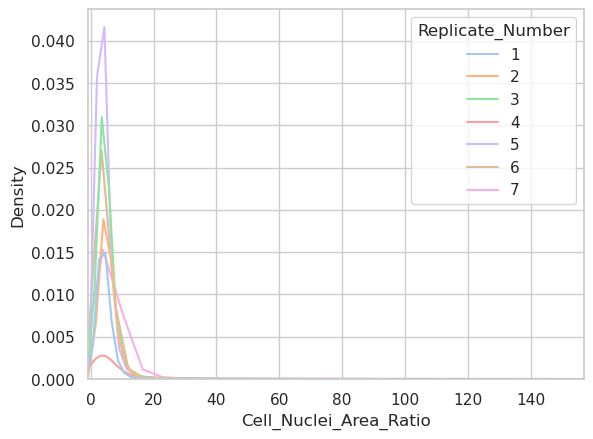

[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]


/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

28.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/tmp/ipykernel_4946/237967217.py:199: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

28.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning:

16.7% of the points cannot b

Kruskal-Wallis H statistic: 15.409454796411325
Kruskal-Wallis p value: 0.05165610224351672
Kruskal-Wallis test is not significant, skipping Dunn's post-hoc test.
No significant pairs found for the dunn test.
[('P6-10', 'P11-13'), ('P6-10', 'P14-16'), ('P6-10', 'P17-19'), ('P6-10', 'P20-22'), ('P6-10', 'P23-25'), ('P6-10', 'P26-28'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P11-13', 'P14-16'), ('P11-13', 'P17-19'), ('P11-13', 'P20-22'), ('P11-13', 'P23-25'), ('P11-13', 'P26-28'), ('P11-13', 'P29+'), ('P11-13', 'Doxo'), ('P14-16', 'P17-19'), ('P14-16', 'P20-22'), ('P14-16', 'P23-25'), ('P14-16', 'P26-28'), ('P14-16', 'P29+'), ('P14-16', 'Doxo'), ('P17-19', 'P20-22'), ('P17-19', 'P23-25'), ('P17-19', 'P26-28'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P20-22', 'P23-25'), ('P20-22', 'P26-28'), ('P20-22', 'P29+'), ('P20-22', 'Doxo'), ('P23-25', 'P26-28'), ('P23-25', 'P29+'), ('P23-25', 'Doxo'), ('P26-28', 'P29+'), ('P26-28', 'Doxo'), ('P29+', 'Doxo')]
Kruskal-Wallis H statistic: 13.01828847

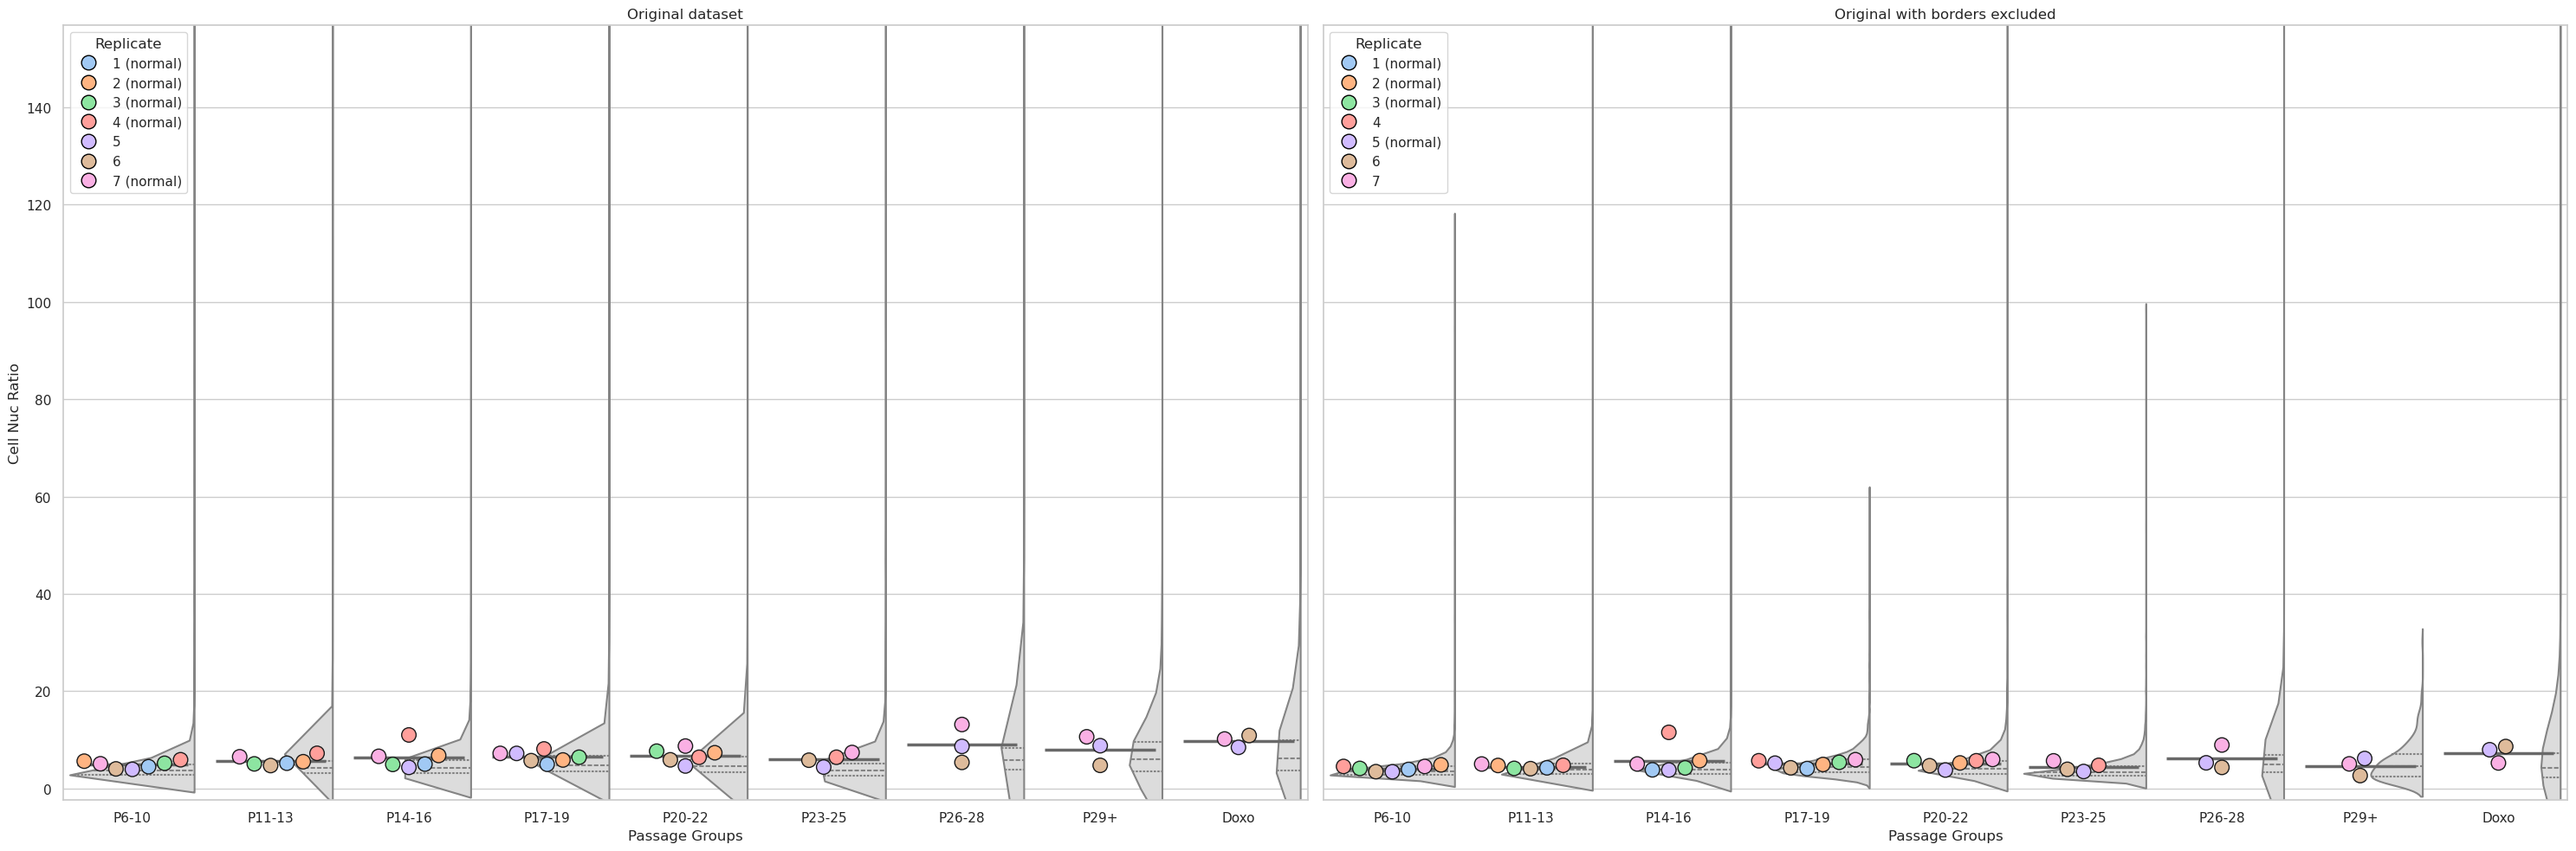

In [81]:
def superplot_for_area_threshold_comparisons(
    data_df_1,
    group_avg_df_1,
    data_df_2,
    group_avg_df_2,
    x_value="AllGroups",
    y_value="Cell_AreaShape_Area",
    replicate_col_name="Replicate_Number",
    out_dir="",
    xtitle=None,
    ytitle=None,
    order=None,
    legend=True,
    title1="Original Dataset",
    title2="Excluding Cells Touching Borders",
    feature_name="cell_area",
    annotate=False,
    test=None,
    export_pivot=False,
    show_hist=False,
):
    """Make two side-by-side superplots to compare area between different conditions
    Args:
        data_df_1 (_type_): _description_
        group_avg_df_1 (_type_): _description_
        data_df_2 (_type_): _description_
        group_avg_df_2 (_type_): _description_
        x_value (str, optional): _description_. Defaults to "AllGroups".
        y_value (str, optional): _description_. Defaults to "Cell_AreaShape_Area".
        replicate_col_name (str, optional): _description_. Defaults to "Replicate_Number".
        csv_dir (str, optional): _description_. Defaults to "".
        xtitle (_type_, optional): _description_. Defaults to None.
        ytitle (_type_, optional): _description_. Defaults to None.
    """
    import matplotlib.lines as mlines
    from statannotations.Annotator import Annotator
    from statannotations.stats.StatTest import StatTest

    if order == None:
        order = get_all_group_order()
    pairs = getpairs(data_df_1, x_value, order=order)
    print(pairs)

    bottom_fence = min(
        -np.percentile(data_df_1[y_value], 10), -np.percentile(data_df_2[y_value], 10)
    )
    top_fence = max(
        np.percentile(data_df_1[y_value], 99.9), np.percentile(data_df_2[y_value], 99.9)
    )
    axlim = (bottom_fence,top_fence)
    if show_hist:
        hist = sns.kdeplot(
            data_df_1, x=y_value, hue=replicate_col_name, palette="pastel"
        )
        plt.xlim(-1,top_fence)
        plt.show()
        plt.close(hist.figure)
        
        df_sorted = data_df_1.sort_values(
            by=[x_value], key=lambda x: x.map(passage_groups_sort_key)
        ).reset_index(drop=True)
        
        import kaleido
        hist2 = px.histogram(
            df_sorted,
            x=y_value,
            color=x_value,
            marginal="box",
            #histnorm='probability density',
            range_x=(-1,top_fence)
            )
        hist2.write_image(Path(out_dir,f"{title1}_{feature_shortname}_histogram.png"), scale=1.5)
        hist2.show()
        
    fig, axes = plt.subplots(1, 2, figsize=(30, 10), sharey=True, sharex=False)
    # plt.style.use("ggplot")
    sns.set_context("talk", font_scale=1.2)
    sns.set_theme(style="whitegrid")

    # First subplot: Full Dataset
    # sns.stripplot(
    #     data=data_df_1,
    #     x=x_value, y=y_value, hue=x_value,
    #     palette="Set2",
    #     order=order,
    #     ax=axes[0],
    # )
    axes[0] = superviolinplot_helper(
        data_df_1,
        group_avg_df_1,
        axes[0],
        x_value,
        y_value,
        title1,
        replicate_col_name,
        order=order,
        annotate=annotate,
        test=test,
    )
    axes[1] = superviolinplot_helper(
        data_df_2,
        group_avg_df_2,
        axes[1],
        x_value,
        y_value,
        title2,
        replicate_col_name,
        order=order,
        annotate=annotate,
        test=test,
    )

    axes[0].set_title(title1)
    axes[1].set_title(title2)

    if legend:
        axes[0] = annotate_legend_with_shapiro(
            axes[0], group_avg_df_1, replicate_col_name
        )
        axes[1] = annotate_legend_with_shapiro(
            axes[1], group_avg_df_2, replicate_col_name
        )
    else:
        axes[0].legend_.remove()
    if ytitle is not None:
        ytitle = ytitle.replace("_"," ").title()
        axes[0].set_ylabel(ytitle)
    if xtitle is not None:
        axes[0].set_xlabel(xtitle)
        axes[1].set_xlabel(xtitle)

    plt.tight_layout()
    plt.ylim(axlim)
    plt.savefig(os.path.join(out_dir, f"combined_{feature_name}_boxplots_{title2}_{test}.png"))
    plt.show()
    if export_pivot:
        pivot_dir = os.path.join(out_dir, "pivot_tables")
        pivot_dir = Path(pivot_dir)
        Path.mkdir(pivot_dir, exist_ok=True)
        group_avg_df_1_pivot = average_groups_pivot(
            group_avg_df_1, x_value, y_value, replicate_col_name
        )
        group_avg_df_2_pivot = average_groups_pivot(
            group_avg_df_2, x_value, y_value, replicate_col_name
        )
        group_avg_df_1_pivot.to_csv(
            os.path.join(pivot_dir, f"area_pivot_{title1}.csv")
        )  # can plop this into graphpad and see what it tells me
        group_avg_df_2_pivot.to_csv(os.path.join(pivot_dir, f"area_pivot_{title2}.csv"))


superplot_for_area_threshold_comparisons(
    combined_cell_df_mitolyso,
    group_avg_area_df,
    combined_cell_df_mitolyso_borders_excluded,
    group_avg_area_df_borders_excluded,
    x_value="AllGroups",
    y_value=feature_name,
    out_dir=summary_outpath,
    xtitle="Passage Groups",
    ytitle=feature_shortname,
    feature_name=feature_shortname,
    title1="Original dataset",
    title2="Original with borders excluded",
    annotate=True,
    test="dunn",
    export_pivot=True,
    show_hist=True,
)


## Make plots and csvs for the comparison btwn regular images and the stitched images

,ImageNumber,Cell_Number_Object_Number,Cell_AreaShape_Area,Cell_AreaShape_BoundingBoxArea,Cell_AreaShape_BoundingBoxMaximum_X,Cell_AreaShape_BoundingBoxMaximum_Y,Cell_AreaShape_BoundingBoxMinimum_X,Cell_AreaShape_BoundingBoxMinimum_Y,Cell_AreaShape_Center_X,Cell_AreaShape_Center_Y,...,Image_PathName_WGA_MAX,Image_Scaling_WGA,Image_Scaling_WGA_MAX,Image_Series_WGA,Image_Series_WGA_MAX,Image_URL_WGA,Image_URL_WGA_MAX,Image_Width_WGA,Image_Width_WGA_MAX,Image_ExecutionTime_20OverlayObjects
262,282,1,105038.0,168916.0,2097.0,484.0,1748.0,0.0,1906.292570,179.904301,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
263,284,1,41024.0,65240.0,857.0,1592.0,624.0,1312.0,742.475039,1454.442521,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
266,283,1,725171.0,2140600.0,1529.0,2160.0,0.0,760.0,727.942654,1518.719519,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
267,288,1,202935.0,425257.0,769.0,1089.0,0.0,536.0,352.617853,776.661769,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
268,285,1,15916.0,20961.0,1457.0,681.0,1320.0,528.0,1389.586705,603.092234,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52310,1638,1,141092.0,195000.0,2160.0,1157.0,1848.0,532.0,2011.086561,891.630192,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52311,1630,1,1242877.0,3432165.0,2137.0,1705.0,124.0,0.0,1185.050619,643.465368,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52312,1630,2,183349.0,471648.0,867.0,2160.0,0.0,1616.0,386.791938,1945.941690,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52313,1639,1,88651.0,146095.0,479.0,305.0,0.0,0.0,172.767527,114.476419,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


[('P6-10', 'P17-19'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P17-19'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P29+', 'Doxo')]
ANOVA F statistic: 4.83176803673186
ANOVA p value: 0.033269920786545316
P6-10 vs. Doxo: Custom statistical test, P_val:2.960e-02
[('P6-10', 'P17-19'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P29+', 'Doxo')]
ANOVA F statistic: 7.237067066531207
ANOVA p value: 0.01145343703153748


/tmp/ipykernel_4946/237967217.py:199: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



P6-10 vs. Doxo: Custom statistical test, P_val:1.050e-02


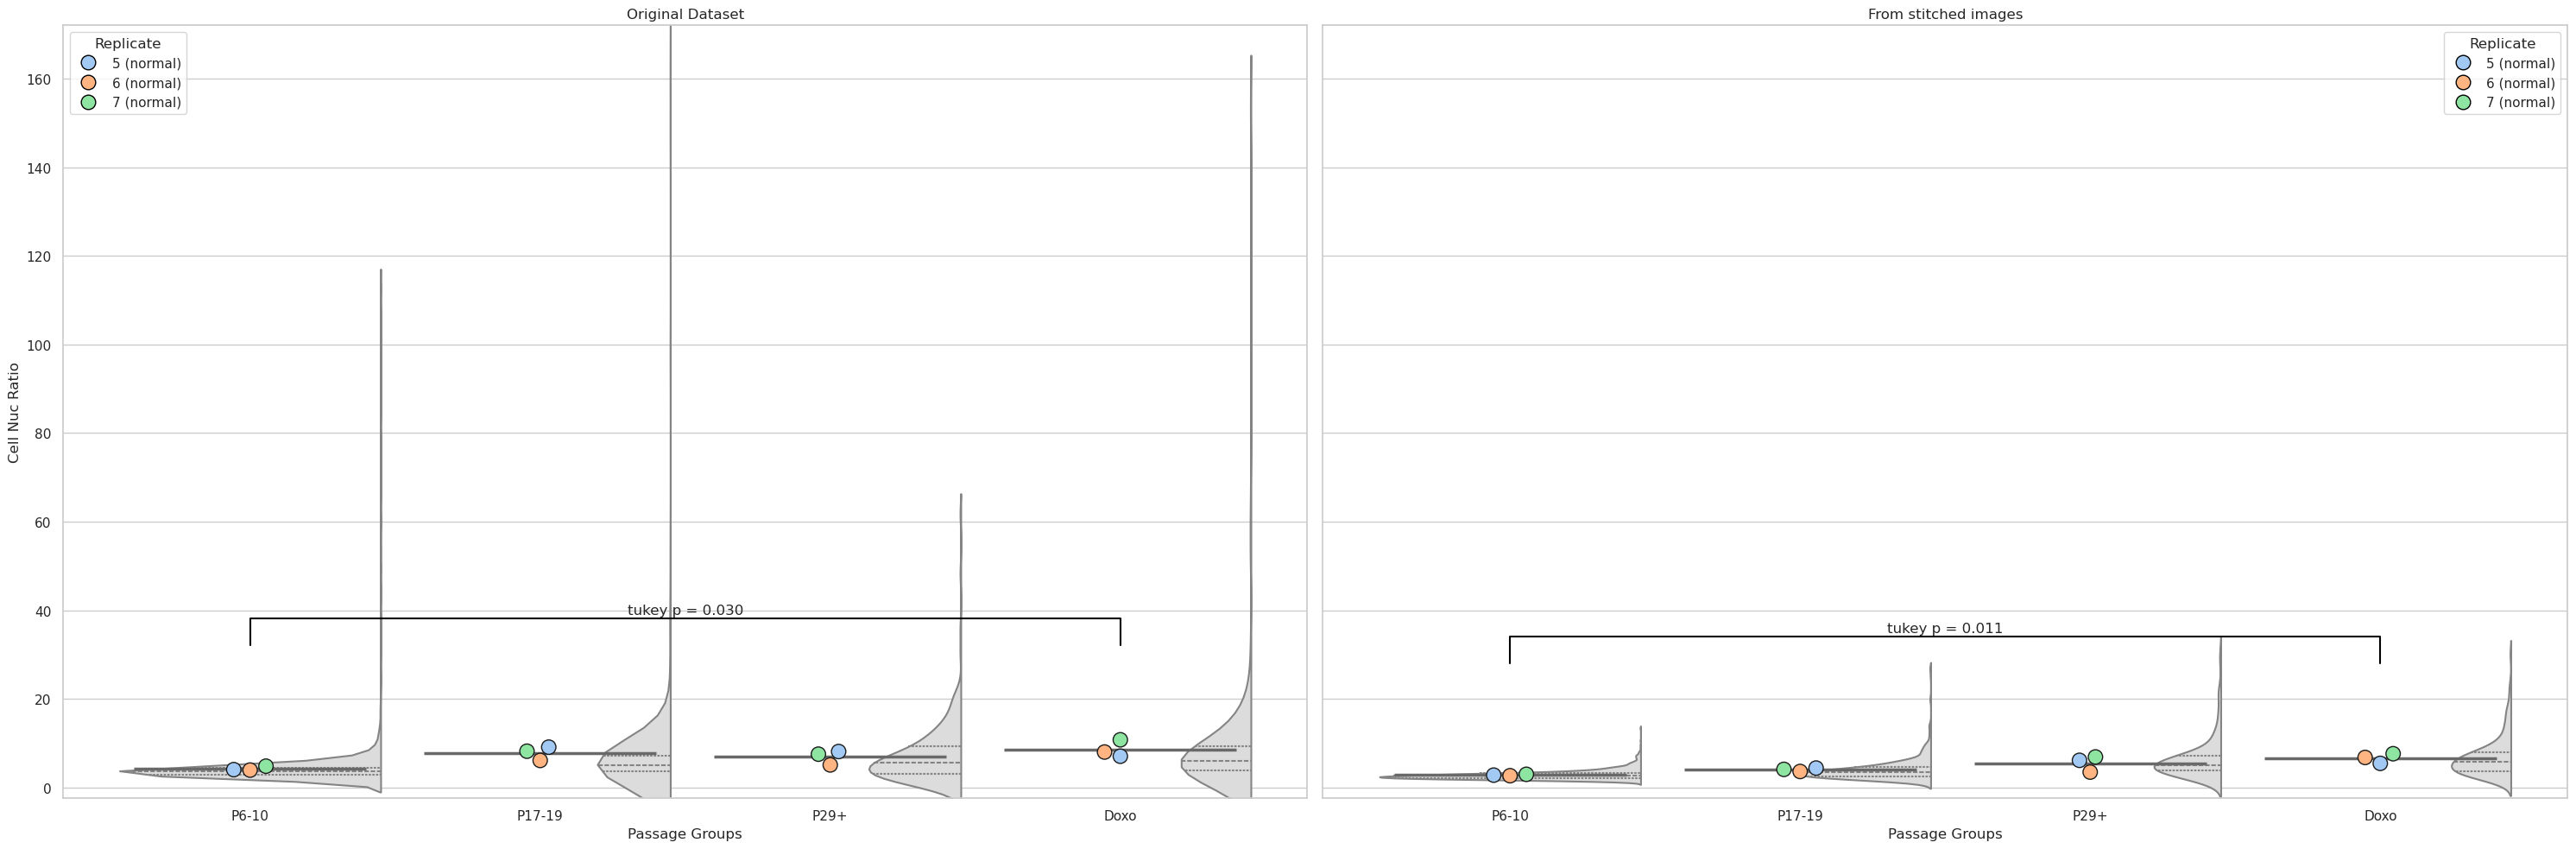

In [82]:
# Match the subset used in the original dataset with the subset used in the stitched images 
# MAKE SURE TO FILTER df BEFORE MAKING THE SUBSET!!
combined_cell_df_mitolyso_subset_extrawells = combined_cell_df_mitolyso[
    combined_cell_df_mitolyso["TimepointName"].isin(
        filtered_related_stiched_cells_df["TimepointName"]
    )
    
]
combined_cell_df_mitolyso_subset = combined_cell_df_mitolyso_subset_extrawells[
    combined_cell_df_mitolyso_subset_extrawells["Metadata_Well_x"].isin(
        related_stiched_cells_df["Metadata_Well_x"]
    )
]
combined_cell_df_mitolyso_subset_borders_excluded = exclude_borders(
    combined_cell_df_mitolyso_subset,
    min_x=min_x,
    max_x=max_x,
    min_y=min_y,
    max_y=max_y
)
display(combined_cell_df_mitolyso_subset)
group_avg_df_subset = get_aggregated_feature_stats_withshaprio(
    combined_cell_df_mitolyso_subset,
    x_value="AllGroups",
    feature=feature_name,
    replicate_col_name="Replicate_Number"
)
#display(group_avg_df_subset)

(
    filtered_group_avg_area_df_subset,
    filtered_group_avg_area_df_subset_borders_excluded,
    filtered_related_stitch_group_avg_area_df,
    filtered_related_stitch_group_avg_area_df_borders_excluded,
) = get_agg_dfs_for_four_comparisons(
    combined_cell_df_mitolyso_subset,
    combined_cell_df_mitolyso_subset_borders_excluded,
    filtered_related_stiched_cells_df,
    filtered_related_stiched_cells_df_borders_excluded,
    x_value="AllGroups",
    feature=feature_name,
)
 
superplot_for_area_threshold_comparisons(
    combined_cell_df_mitolyso_subset,
    filtered_group_avg_area_df_subset,
    filtered_related_stiched_cells_df,
    filtered_related_stitch_group_avg_area_df,
    out_dir=summary_outpath,
    x_value="AllGroups",
    y_value=feature_name,
    order=["P6-10", "P17-19", "P29+", "Doxo"],
    title2="From stitched images",
    annotate=True,
    test="tukey",
    export_pivot=True,
    xtitle="Passage Groups",
    ytitle=feature_shortname,
    feature_name=feature_shortname
)

# stitched_cells_df.to_csv(os.path.join(csv_outpath, "stitched_cells.csv"), index=False)
# stitched_cells_df.describe().to_csv(
#     os.path.join(summary_outpath, "stitched_cell_stats.csv")
# )
# stitched_cells_df.groupby("AllGroups")["Cell_AreaShape_Area"].describe().to_csv(
#     os.path.join(summary_outpath, "stitched_cell_passage_group_stats.csv")
# )


(3080, 86)

(2876, 86)

[('P6-10', 'P17-19'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P17-19'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P29+', 'Doxo')]
ANOVA F statistic: 7.237067066531207
ANOVA p value: 0.01145343703153748
P6-10 vs. Doxo: Custom statistical test, P_val:1.050e-02
[('P6-10', 'P17-19'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P29+', 'Doxo')]


/tmp/ipykernel_4946/237967217.py:199: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



ANOVA F statistic: 7.348005317812306
ANOVA p value: 0.010971063694255417
P6-10 vs. P29+: Custom statistical test, P_val:4.250e-02
P6-10 vs. Doxo: Custom statistical test, P_val:1.130e-02


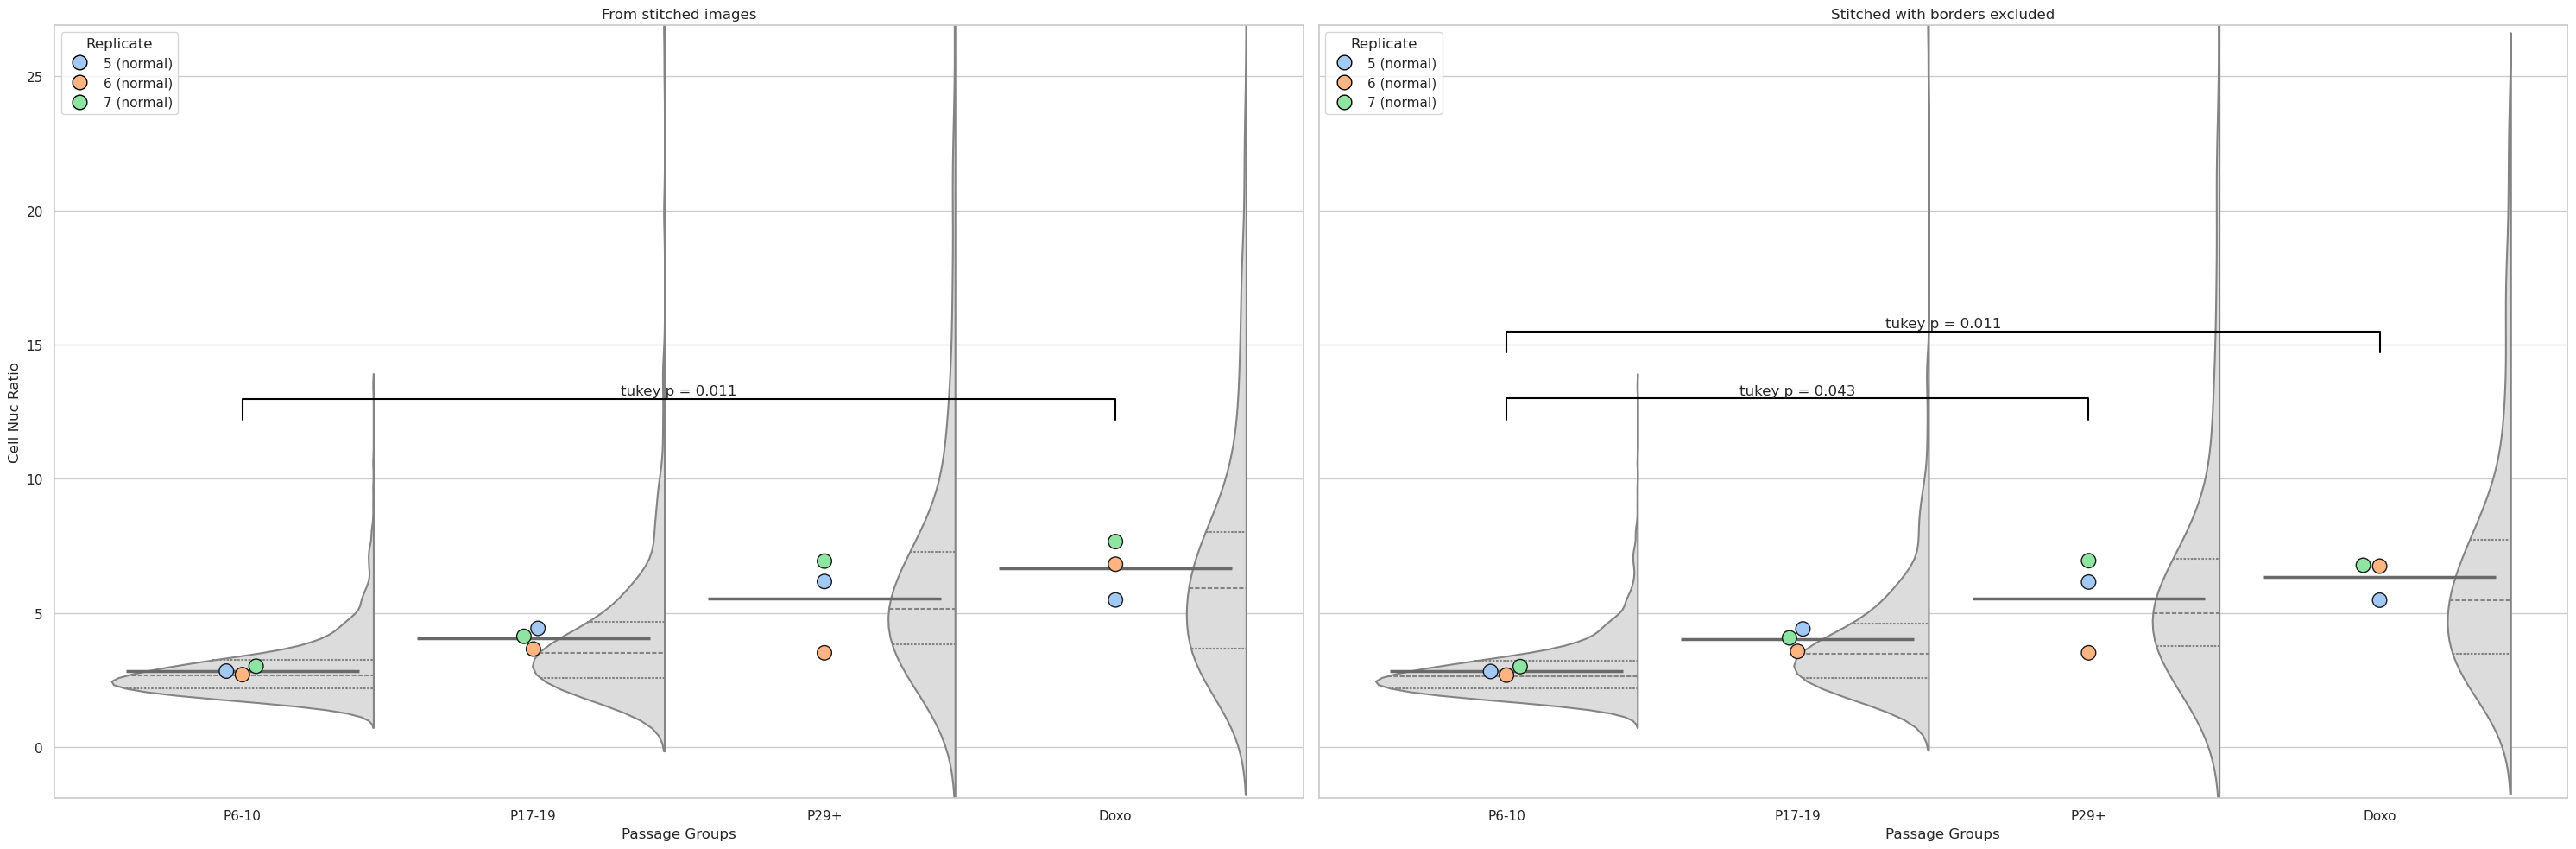

In [83]:
#Compare stitched cells to stitched cells with borders excluded
display(
    filtered_related_stiched_cells_df.shape,
    filtered_related_stiched_cells_df_borders_excluded.shape
) #make sure they aren't the same size to validate

superplot_for_area_threshold_comparisons(
    filtered_related_stiched_cells_df,
    filtered_related_stitch_group_avg_area_df,
    filtered_related_stiched_cells_df_borders_excluded,
    filtered_related_stitch_group_avg_area_df_borders_excluded,
    order=["P6-10", "P17-19", "P29+", "Doxo"],
    title1="From stitched images",
    title2="Stitched with borders excluded",
    out_dir=summary_outpath,
    x_value="AllGroups",
    y_value=feature_name,
    xtitle="Passage Groups",
    ytitle= feature_shortname,
    annotate=True,
    test="tukey",
    export_pivot=True,
    feature_name=feature_shortname
    #show_hist=True,
)

# stitched_cells_df_borders_excluded.to_csv(
#     os.path.join(csv_outpath, "stitched_cells_borders_excluded.csv"), index=False
# )
# stitched_cells_df_borders_excluded.describe().to_csv(
#     os.path.join(summary_outpath, "stitched_cells_borders_excluded_stats.csv")
# )
# stitched_cells_df_borders_excluded.groupby("AllGroups")[
#     "Cell_AreaShape_Area"
# ].describe().to_csv(
#     os.path.join(summary_outpath, "stitched_cell_borders_excluded_passage_group_stats.csv")
# )



[('P6-10', 'P17-19'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P29+', 'Doxo')]
[('P6-10', 'P17-19'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P29+', 'Doxo')]
ANOVA F statistic: 4.83176803673186
ANOVA p value: 0.033269920786545316
P6-10 vs. Doxo: Custom statistical test, P_val:2.960e-02
[('P6-10', 'P17-19'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P29+', 'Doxo')]


/tmp/ipykernel_4946/237967217.py:199: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

/tmp/ipykernel_4946/237967217.py:199: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



ANOVA F statistic: 1.6770641848580579
ANOVA p value: 0.24823383226862272
ANOVA test is not significant, skipping Tukey's HSD post-hoc test.
No significant pairs found for the tukey test.
[('P6-10', 'P17-19'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P29+', 'Doxo')]
ANOVA F statistic: 7.237067066531207
ANOVA p value: 0.01145343703153748
P6-10 vs. Doxo: Custom statistical test, P_val:1.050e-02


/tmp/ipykernel_4946/237967217.py:199: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



[('P6-10', 'P17-19'), ('P6-10', 'P29+'), ('P6-10', 'Doxo'), ('P17-19', 'P29+'), ('P17-19', 'Doxo'), ('P29+', 'Doxo')]
ANOVA F statistic: 7.348005317812306
ANOVA p value: 0.010971063694255417
P6-10 vs. P29+: Custom statistical test, P_val:4.250e-02
P6-10 vs. Doxo: Custom statistical test, P_val:1.130e-02


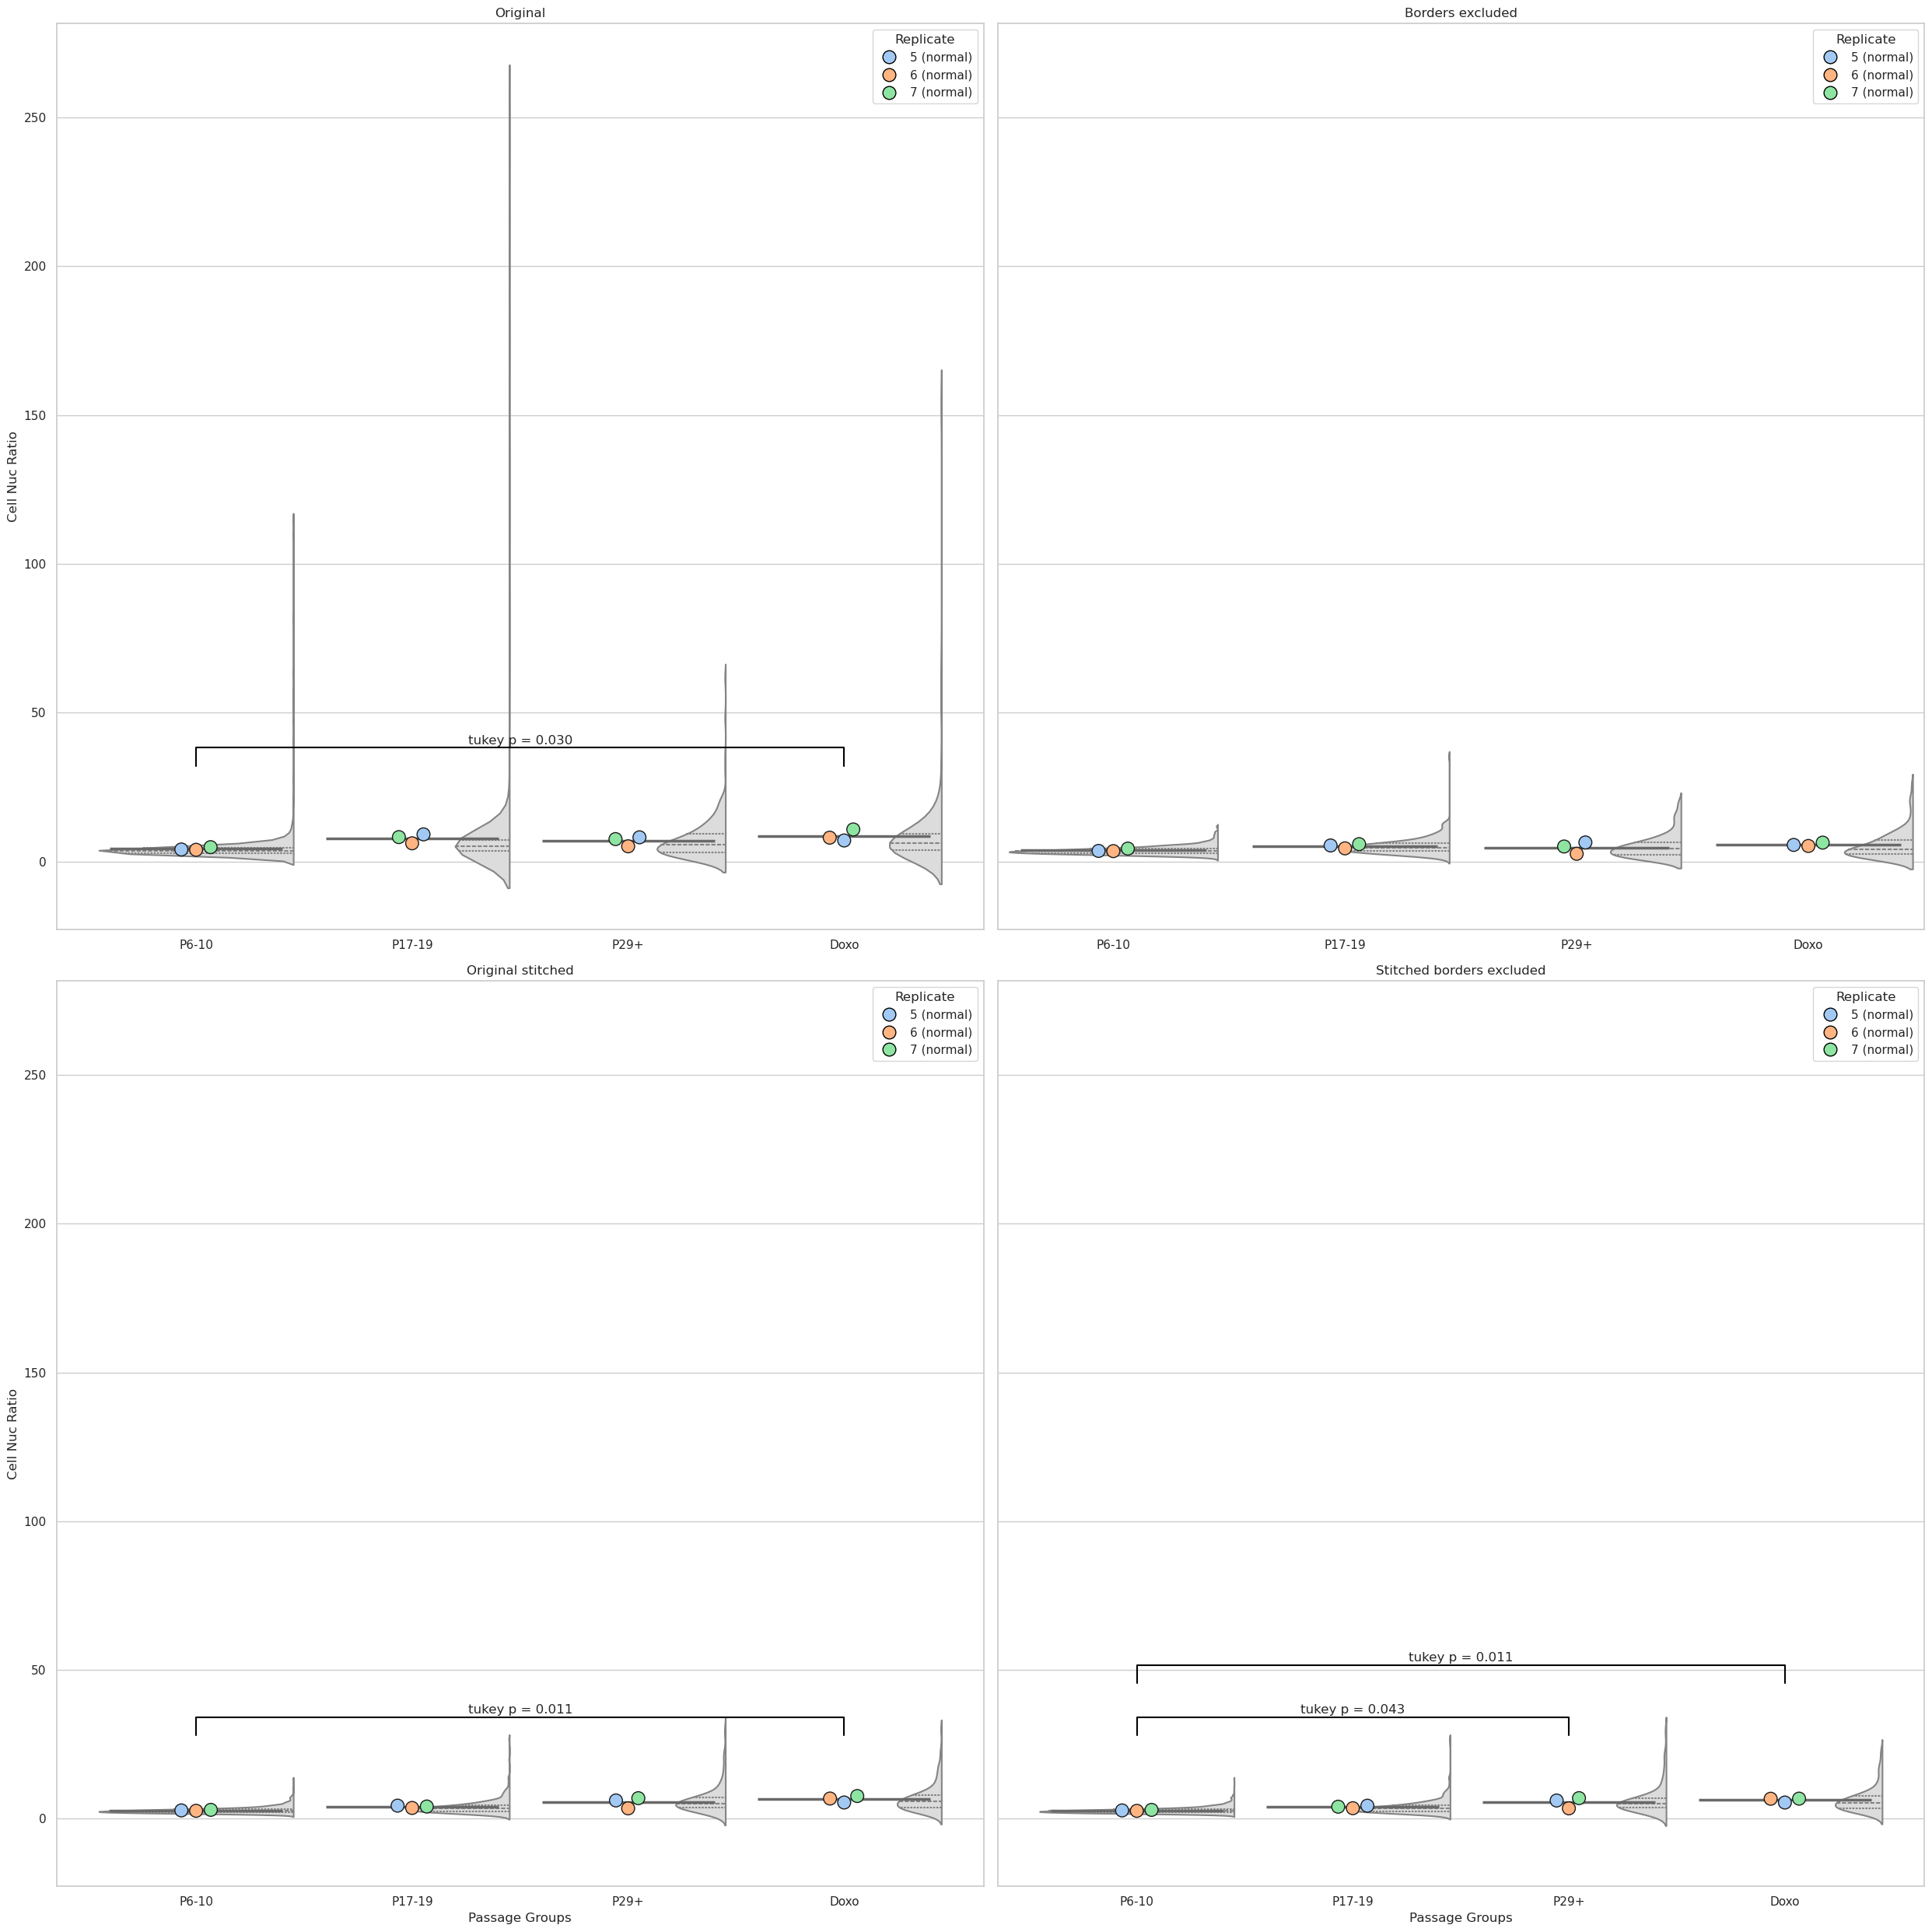

In [84]:
def fourxfour_superplot_for_area_threshold_comparisons_helper(
    dfs,
    group_avg_dfs,
    x_value="AllGroups",
    y_value="Cell_AreaShape_Area",
    feature_name="cell_area",
    replicate_col_name="Replicate_Number",
    out_dir="",
    xtitle=None,
    ytitle=None,
    order=None,
    legend=True,
    titles=["Original Dataset","Excluding Cells Touching Borders"],
    annotate=False,
    test=None,
    savetitle = "4x4",
    export_pivot=False,
    show_hist=False,
):
    """Make two side-by-side superplots to compare area between different conditions
    Args:
        data_df_1 (_type_): _description_
        group_avg_df_1 (_type_): _description_
        data_df_2 (_type_): _description_
        group_avg_df_2 (_type_): _description_
        x_value (str, optional): _description_. Defaults to "AllGroups".
        y_value (str, optional): _description_. Defaults to "Cell_AreaShape_Area".
        replicate_col_name (str, optional): _description_. Defaults to "Replicate_Number".
        csv_dir (str, optional): _description_. Defaults to "".
        xtitle (_type_, optional): _description_. Defaults to None.
        ytitle (_type_, optional): _description_. Defaults to None.
    """
    import matplotlib.lines as mlines
    from statannotations.Annotator import Annotator
    from statannotations.stats.StatTest import StatTest
    
    if order == None:
        order = get_all_group_order()
    pairs = getpairs(dfs[0], x_value, order=order)
    print(pairs)
    
    fig, axes = plt.subplots(2, 2, figsize=(25, 25), sharey=True, sharex=False)
    # plt.style.use("ggplot")
    sns.set_context("poster", font_scale=1.2)
    sns.set_theme(style="whitegrid")

    for i,df in enumerate(dfs):
        if show_hist:
            hist = sns.kdeplot(
                df, x=y_value, hue=replicate_col_name, palette="pastel"
            )
            plt.show()
            plt.close(hist.figure)

            hist2 = px.histogram(df, x=y_value, color=x_value)
            hist2.show()
        if i == 0:
            ax_ind = (i,i)
        elif i == 1:
            ax_ind = (0,i)
        elif i == 2:
            ax_ind = (1,0)
        else:
            ax_ind = (1,1)
        
        axes[ax_ind] = superviolinplot_helper(
            df,
            group_avg_dfs[i],
            axes[ax_ind],
            x_value,
            y_value,
            titles[i],
            replicate_col_name,
            order=order,
            annotate=annotate,
            test=test,
        )
        axes[ax_ind].set_title(titles[i])
        if legend:
            axes[ax_ind] = annotate_legend_with_shapiro(
                axes[ax_ind], group_avg_dfs[i], replicate_col_name
            )
        else:
            axes[ax_ind].legend_.remove()
        if ytitle is not None:
            ytitle = ytitle.replace("_", " ").title()
            axes[ax_ind].set_ylabel(ytitle)
        if xtitle is not None and i > 1:
            axes[ax_ind].set_xlabel(xtitle)
        else:
            axes[ax_ind].set_xlabel(None)

    plt.tight_layout()
    plt.savefig(
        os.path.join(out_dir, f"combined_{feature_name}_boxplots_{savetitle}_{test}.png")
    )
    plt.show()
    return axes

dfs = [combined_cell_df_mitolyso_subset,combined_cell_df_mitolyso_subset_borders_excluded,filtered_related_stiched_cells_df,filtered_related_stiched_cells_df_borders_excluded]
group_dfs=[filtered_group_avg_area_df_subset,filtered_group_avg_area_df_subset_borders_excluded,filtered_related_stitch_group_avg_area_df,filtered_related_stitch_group_avg_area_df_borders_excluded]
titles =["Original","Borders excluded","Original stitched", "Stitched borders excluded"]

axes = fourxfour_superplot_for_area_threshold_comparisons_helper(
    dfs,
    group_dfs,
    out_dir=summary_outpath,
    x_value="AllGroups",
    y_value=feature_name,
    order=["P6-10", "P17-19", "P29+", "Doxo"],
    titles = titles,
    annotate=True,
    test="tukey",
    export_pivot=False,
    xtitle="Passage Groups",
    ytitle=feature_shortname,
    feature_name=feature_shortname
)

#fig,aaxes = plt.subplots(2,2,(50,20))
